# Análisis de la Encuesta de Competencias Financieras 2021

¿Es necesario adaptar nuestras ofertas actuales o crear nuevas en función de las tendencias nacionales en comportamiento financiero y competencias financieras?

## Librerias

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import chi2_contingency
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import kruskal
import statsmodels.formula.api as smf


## Carga del fichero csv

In [2]:
## Carga del dataset Gold

df = pd.read_csv(
    r"..\Data\Gold_ECF_090226.csv",
    sep=","
)

df.shape


(7554, 74)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7554 entries, 0 to 7553
Data columns (total 74 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   cat_educacion          7554 non-null   object 
 1   estado_laboral         7554 non-null   object 
 2   familia                7554 non-null   object 
 3   riq_inmob              7554 non-null   object 
 4   ahorro                 7554 non-null   int64  
 5   deuda                  7554 non-null   int64  
 6   adq_ahorro2            7554 non-null   int64  
 7   adq_deuda2             7554 non-null   int64  
 8   adq_otro               7554 non-null   int64  
 9   ahorra_12m             7554 non-null   int64  
 10  consumo_ahorros        7554 non-null   int64  
 11  cred_inf               7554 non-null   int64  
 12  cred_form              7554 non-null   int64  
 13  cred_add               7554 non-null   int64  
 14  impago                 7554 non-null   int64  
 15  ayud

In [4]:
df.head()

,cat_educacion,estado_laboral,familia,riq_inmob,ahorro,deuda,adq_ahorro2,adq_deuda2,adq_otro,ahorra_12m,...,idx_estres_financiero,idx_uso_credito,idx_ahorro,score_ahorro,score_inversion,score_credito,actividad_score,actividad,complejidad,comp_prod
0,Universidad,Asalariado,Vive con pareja,Solo residencia principal,0,1,0,1,1,1,...,1,2,1,1,0,3,4,1,1,1
1,Universidad,Asalariado,Otros adultos,Residencia principal y otras,0,1,0,0,0,0,...,1,1,0,0,0,2,2,1,1,1
2,Educación Secundaria,Asalariado,Vive solo,Residencia principal y otras,1,0,1,0,1,1,...,0,0,3,2,7,0,9,1,1,1
3,Educación Secundaria,Asalariado,Vive con pareja,Solo residencia principal,1,1,0,0,0,1,...,0,1,2,0,2,1,3,1,1,1
4,Educación Primaria,Asalariado,Otros adultos,Solo residencia principal,0,1,0,1,1,0,...,1,3,0,0,0,3,3,1,1,1


In [5]:
df.columns.tolist()

['cat_educacion',
 'estado_laboral',
 'familia',
 'riq_inmob',
 'ahorro',
 'deuda',
 'adq_ahorro2',
 'adq_deuda2',
 'adq_otro',
 'ahorra_12m',
 'consumo_ahorros',
 'cred_inf',
 'cred_form',
 'cred_add',
 'impago',
 'ayudas',
 'rechazo',
 'semirechazo',
 'nopiden',
 'age',
 'ID',
 'year',
 'inflacion_ok',
 'interes_comp_ok',
 'diversificacion_ok',
 'weight',
 't_hipoteca',
 't_ppension_ind',
 't_ppension_emp',
 't_fondo_inv',
 't_acciones',
 't_prestamo',
 't_renta_fija',
 't_cuentas_depositos',
 'adq_hipoteca',
 'adq_ppension_ind',
 'adq_ppension_emp',
 'adq_fondo_inv',
 'adq_acciones',
 'adq_prestamo',
 'adq_otros_act',
 'adq_renta_fija',
 'adq_cuentas_depositos',
 'uso_cc',
 'uso_ahorro_dep',
 'venta_activos',
 'prestamo_fam',
 'prestamo_amig',
 'tarjeta_cred',
 'descubierto_auto',
 'prest_garantia',
 'linea_cred',
 'prest_banc',
 'prest_nobanc',
 'otro_prest',
 'edad_grupo',
 'score_comp_fin',
 'nivel_comp_fin',
 'comp_fin_bin',
 'prestamo_gastos',
 'morosidad',
 'denegacion_credito

## 2. Indicador de competencia financiera

El indicador de competencia financiera se construye a partir de tres preguntas estándar sobre:

- Inflación
- Interés compuesto
- Diversificación del riesgo

Cada respuesta correcta suma un punto, generando una puntuación total entre 0 y 3.

A partir de esta puntuación se derivan:

- Un indicador categórico (bajo, medio, alto).
- Un indicador binario (`comp_fin_bin`), donde:
  - 1 = competente (score ≥ 2)
  - 0 = no competente (score ≤ 1)

Este indicador permite analizar la relación entre conocimiento financiero, comportamiento real y vulnerabilidad.


### 2.1 Distribución del nivel de competencia


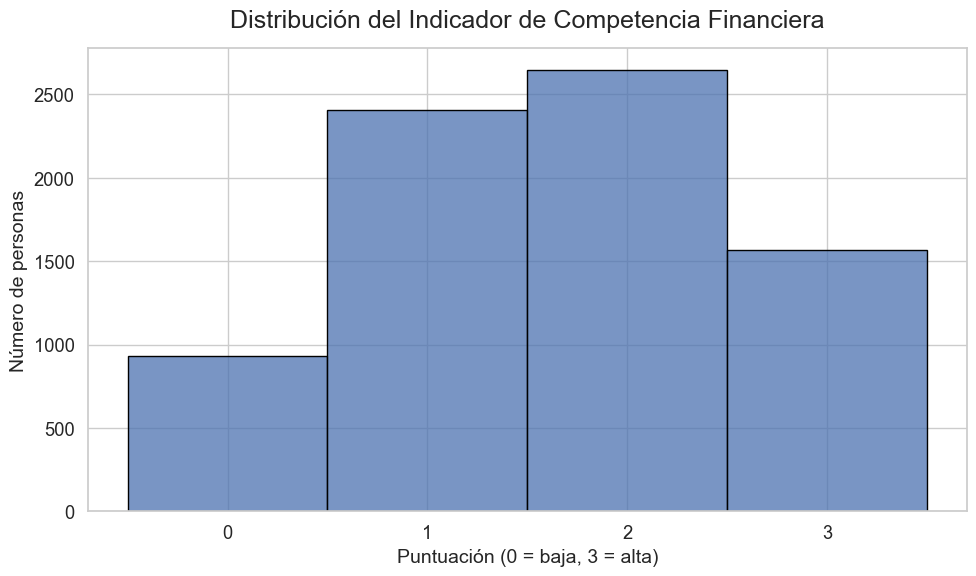

In [6]:
# Estilo general
sns.set(style="whitegrid", palette="deep", font_scale=1.2)

plt.figure(figsize=(10,6))

# Histograma
sns.histplot(
    data=df,
    x="score_comp_fin",
    bins=[-0.5, 0.5, 1.5, 2.5, 3.5],  # para separar bien 0,1,2,3
    color="#4C72B0",
    kde=False,
    edgecolor="black"
)

# Títulos y etiquetas
plt.title("Distribución del Indicador de Competencia Financiera", fontsize=18, pad=15)
plt.xlabel("Puntuación (0 = baja, 3 = alta)", fontsize=14)
plt.ylabel("Número de personas", fontsize=14)

# Ajustes finales
plt.xticks([0,1,2,3])
plt.tight_layout()
plt.show()

C:\Users\anaferrandbetes\AppData\Local\Temp\ipykernel_3308\1028436493.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


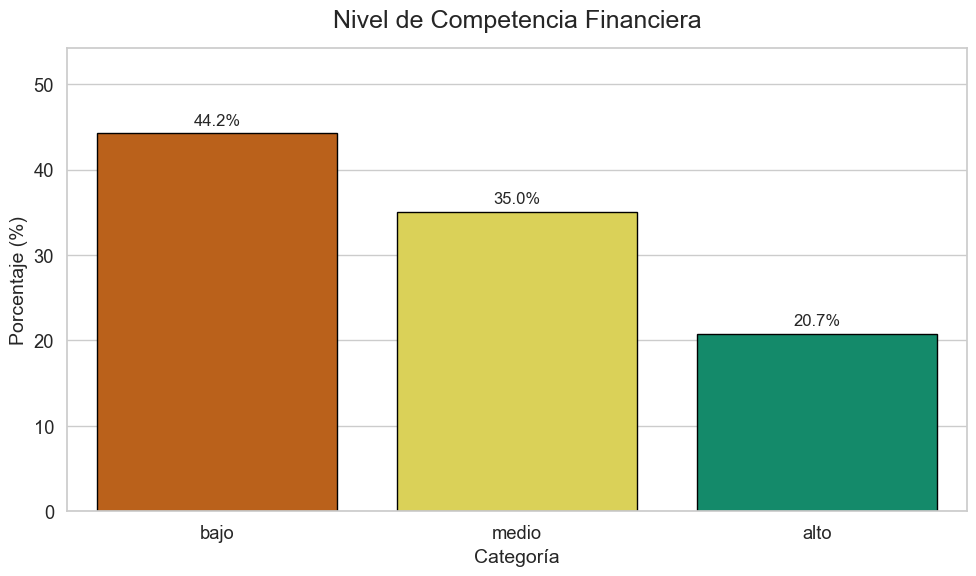

In [7]:

sns.set(style="whitegrid", font_scale=1.2)

# Orden lógico
orden = ["bajo", "medio", "alto"]

# Calcular porcentajes
porc = (
    df["nivel_comp_fin"]
    .value_counts(normalize=True)
    .reindex(orden)
    * 100
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=porc.index,
    y=porc.values,
    palette=["#D55E00", "#F0E442", "#009E73"],  # rojo → amarillo → verde
    edgecolor="black"
)

plt.title("Nivel de Competencia Financiera", fontsize=18, pad=15)
plt.xlabel("Categoría", fontsize=14)
plt.ylabel("Porcentaje (%)", fontsize=14)

# Etiquetas encima de cada barra
for i, v in enumerate(porc.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=12)

plt.ylim(0, porc.max() + 10)
plt.tight_layout()
plt.show()

C:\Users\anaferrandbetes\AppData\Local\Temp\ipykernel_3308\2705371866.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


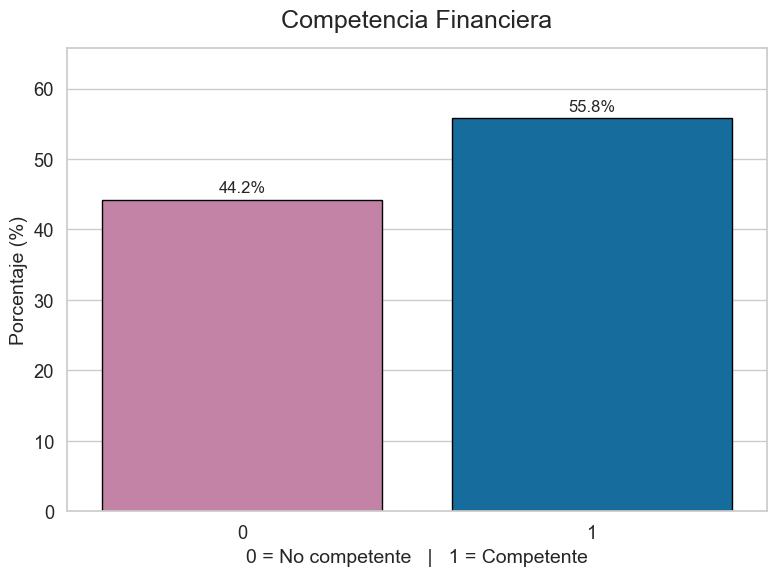

In [8]:
plt.figure(figsize=(8,6))

# Calcular porcentajes
porc_bin = (
    df["comp_fin_bin"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

sns.barplot(
    x=porc_bin.index,
    y=porc_bin.values,
    palette=["#CC79A7", "#0072B2"],  # dos colores contrastados
    edgecolor="black"
)

plt.title("Competencia Financiera", fontsize=18, pad=15)
plt.xlabel("0 = No competente   |   1 = Competente", fontsize=14)
plt.ylabel("Porcentaje (%)", fontsize=14)

# Etiquetas encima de cada barra
for i, v in enumerate(porc_bin.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=12)

plt.ylim(0, porc_bin.max() + 10)
plt.tight_layout()
plt.show()

### 2.2 Competencia financiera por variables sociodemográficas

#### 2.2.1. Nivel educativo

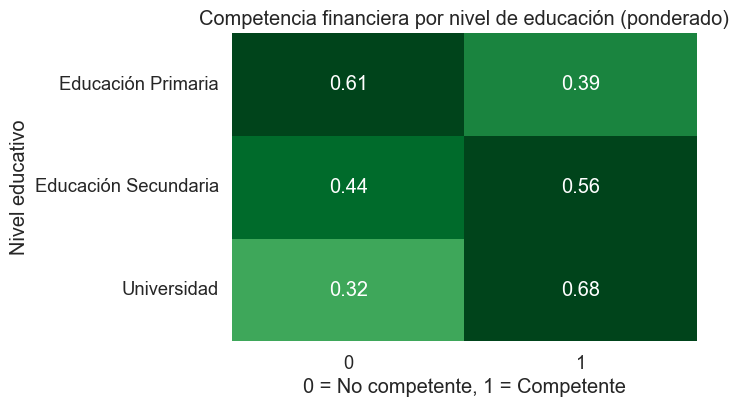

In [9]:
comp_edu_pond = pd.crosstab(
    df["cat_educacion"],
    df["comp_fin_bin"],
    values=df["weight"],
    aggfunc="sum",
    normalize="index"
).round(2)


plt.figure(figsize=(6,4))
sns.heatmap(
    comp_edu_pond,
    annot=True,
    cmap="Greens",
    vmin=0,
    vmax=0.5,
    cbar=False
)

plt.title("Competencia financiera por nivel de educación (ponderado)")
plt.xlabel("0 = No competente, 1 = Competente")
plt.ylabel("Nivel educativo")

plt.show()

#### 2.2.2. Riqueza inmobiliaria

C:\Users\anaferrandbetes\AppData\Local\Temp\ipykernel_3308\2045784005.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["weight"].sum())


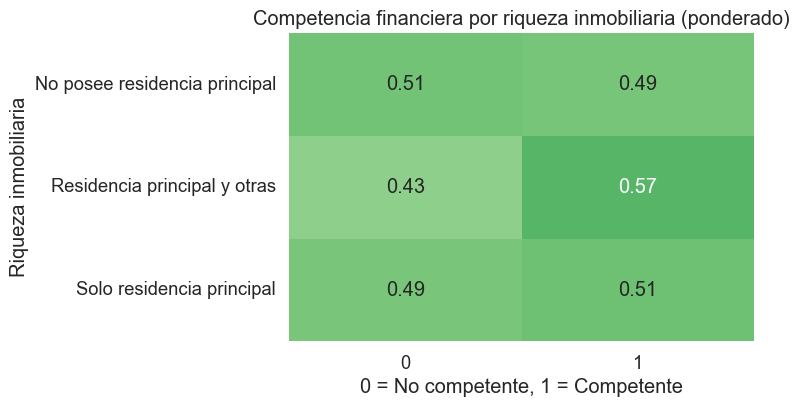

In [10]:
comp_riq_pond = (
    df
    .groupby(["riq_inmob", "comp_fin_bin"])
    .apply(lambda x: x["weight"].sum())
    .unstack(fill_value=0)
)

comp_riq_pond = comp_riq_pond.div(comp_riq_pond.sum(axis=1), axis=0)

plt.figure(figsize=(6,4))
sns.heatmap(
    comp_riq_pond,
    annot=True,
    cmap="Greens",
    vmin=0,
    vmax=1,
    cbar=False
)

plt.title("Competencia financiera por riqueza inmobiliaria (ponderado)")
plt.xlabel("0 = No competente, 1 = Competente")
plt.ylabel("Riqueza inmobiliaria")

plt.show()


#### 2.2.3. Grupo de edad

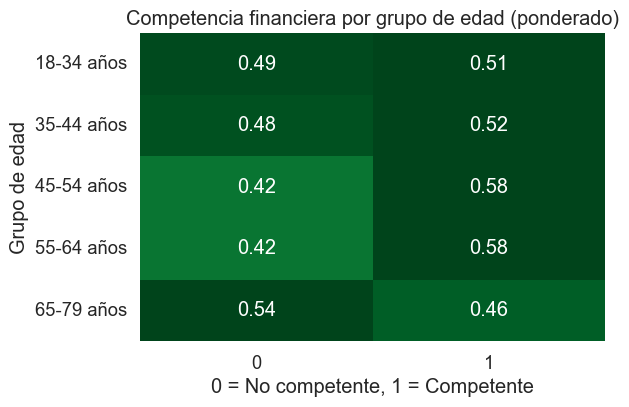

In [11]:
comp_edad_pond = pd.crosstab(
    df["edad_grupo"],
    df["comp_fin_bin"],
    values=df["weight"],
    aggfunc="sum",
    normalize="index"
).round(2)

plt.figure(figsize=(6,4))
sns.heatmap(
    comp_edad_pond,
    annot=True,
    cmap="Greens",
    vmin=0,
    vmax=0.5,
    cbar=False
)

plt.title("Competencia financiera por grupo de edad (ponderado)")
plt.xlabel("0 = No competente, 1 = Competente")
plt.ylabel("Grupo de edad")

plt.show()

#### 2.2.4. Situación laboral

C:\Users\anaferrandbetes\AppData\Local\Temp\ipykernel_3308\3415512844.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["weight"].sum())


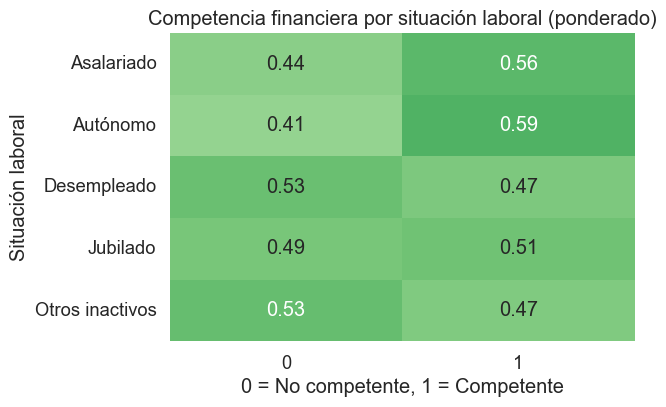

In [12]:
comp_lab_pond = (
    df
    .groupby(["estado_laboral", "comp_fin_bin"])
    .apply(lambda x: x["weight"].sum())
    .unstack(fill_value=0)
)

comp_lab_pond = comp_lab_pond.div(comp_lab_pond.sum(axis=1), axis=0)

plt.figure(figsize=(6,4))
sns.heatmap(
    comp_lab_pond,
    annot=True,
    cmap="Greens",
    vmin=0,
    vmax=1,
    cbar=False
)

plt.title("Competencia financiera por situación laboral (ponderado)")
plt.xlabel("0 = No competente, 1 = Competente")
plt.ylabel("Situación laboral")

plt.show()


#### 2.2.5. Tipo de unidad familiar

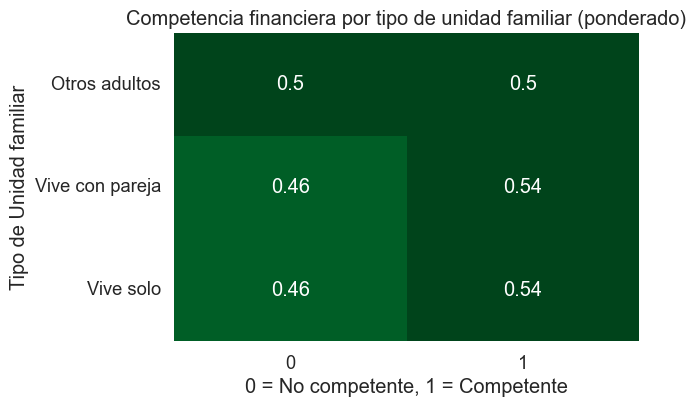

In [13]:
comp_fam_pond = pd.crosstab(
    df["familia"],
    df["comp_fin_bin"],
    values=df["weight"],
    aggfunc="sum",
    normalize="index"
).round(2)


plt.figure(figsize=(6,4))
sns.heatmap(
    comp_fam_pond,
    annot=True,
    cmap="Greens",
    vmin=0,
    vmax=0.5,
    cbar=False
)

plt.title("Competencia financiera por tipo de unidad familiar (ponderado)")
plt.xlabel("0 = No competente, 1 = Competente")
plt.ylabel("Tipo de Unidad familiar")

plt.show()

### 2.3. Tests Estadísticos en la variable Competencia financiera

#### 2.3.1. Chi cuadrado de indendencia + Cramer's V

In [14]:


# Variables a analizar contra competencia (target)
VARIABLES = [
    "cat_educacion",
    "familia",
    "estado_laboral",
    "riq_inmob",
    "edad_grupo"
]

TARGET = "comp_fin_bin"

def test_competencia(df, target, variables):
    resultados = []

    # === BLOQUE 1: construir dataframe temporal ===
    temp = pd.DataFrame()
    temp[target] = df[target]

    for var in variables:
        if var in df.columns:
            temp[var] = df[var]
        elif var in df.columns:
            temp[var] = df[var]
        else:
            continue

    # === BLOQUE 2: análisis ===
    for var in variables:
        if var not in temp.columns:
            continue

        print("\n------------------------------")
        print(f"Test Chi-cuadrado: {target} vs {var}")
        print("------------------------------")

        tabla = pd.crosstab(temp[var], temp[target])
        print("\nTabla de contingencia:")
        print(tabla)

        if tabla.shape[0] < 2 or tabla.shape[1] < 2:
            print("No se puede hacer chi-cuadrado: tabla incompleta")
            resultados.append((var, None, None))
            continue

        chi2, p, dof, expected = chi2_contingency(tabla)

        print(f"\nChi2 = {chi2:.3f}")
        print(f"p-valor = {p:.5f}")
        print(f"Grados de libertad = {dof}")

        if p < 0.05:
            print("Asociación SIGNIFICATIVA (p < 0.05)")
        else:
            print("Asociación NO significativa (p ≥ 0.05)")

        # Cálculo de Cramer's V
        n = tabla.sum().sum()
        r, k = tabla.shape
        cramers_v = np.sqrt(chi2 / (n * (min(r - 1, k - 1))))

        resultados.append((var, p, cramers_v))

    # === BLOQUE 3: resumen final de resultados ===
    print("\n\nResumen final de p-valores:")
    resumen = pd.DataFrame(resultados, columns=["Variable", "p_valor", "Cramers_V"])

    # Añadir columna de significancia
    resumen["Significancia"] = resumen["p_valor"].apply(
        lambda p: "Significativa" if p is not None and p < 0.05 else
                  ("No significativa" if p is not None else "No evaluable")
    )

    print(resumen)
    return resumen


# Ejecutar análisis
resultados = test_competencia(df, TARGET, VARIABLES)


------------------------------
Test Chi-cuadrado: comp_fin_bin vs cat_educacion
------------------------------

Tabla de contingencia:
comp_fin_bin             0     1
cat_educacion                   
Educación Primaria    1505  1009
Educación Secundaria   836  1048
Universidad           1001  2155

Chi2 = 449.440
p-valor = 0.00000
Grados de libertad = 2
Asociación SIGNIFICATIVA (p < 0.05)

------------------------------
Test Chi-cuadrado: comp_fin_bin vs familia
------------------------------

Tabla de contingencia:
comp_fin_bin        0     1
familia                    
Otros adultos     862   925
Vive con pareja  2065  2747
Vive solo         415   540

Chi2 = 15.245
p-valor = 0.00049
Grados de libertad = 2
Asociación SIGNIFICATIVA (p < 0.05)

------------------------------
Test Chi-cuadrado: comp_fin_bin vs estado_laboral
------------------------------

Tabla de contingencia:
comp_fin_bin        0     1
estado_laboral             
Asalariado       1539  2194
Autónomo          335  

##### Conclusiones de Chi cuadrado y Cramer's V
- La competencia financiera está asociada de forma significativa con todas las variables analizadas.
- La educación es el factor más determinante, con la asociación más fuerte y el mayor tamaño del efecto.
- La situación laboral también influye, aunque con un efecto más moderado.
- La edad, la estructura familiar y la riqueza inmobiliaria muestran asociaciones significativas pero de baja intensidad.
- En conjunto, los resultados indican que la competencia financiera no se distribuye de manera uniforme en la población y está condicionada principalmente por el nivel educativo y, en menor medida, por la situación laboral.


#### 2.3.2. Regresión logística

In [15]:
VARIABLES = [
    "cat_educacion",
    "familia",
    "estado_laboral",
    "riq_inmob",
    "edad_grupo"
]

TARGET = "comp_fin_bin"

def regresion_logistica(df, target, variables):

    # === 1. Construir dataframe temporal ===
    temp = pd.DataFrame()
    temp[target] = df[target]

    for var in variables:
        if var in df.columns:
            temp[var] = df[var]
        elif var in df.columns:
            temp[var] = df[var]

    # Eliminar filas con NA
    temp = temp.dropna()

    # === 2. Crear dummies ===
    X = pd.get_dummies(temp[variables], drop_first=True)
    y = temp[target]

    # === 3. Convertir TODO a float ===
    X = X.astype(float)
    y = y.astype(float)

    # Alinear índices 
    X, y = X.align(y, join="inner", axis=0)

    # Añadir constante
    X = sm.add_constant(X)

    # === 4. Ajustar modelo logístico ===
    modelo = sm.Logit(y, X).fit()

    # === 5. Odds ratios e intervalos ===
    params = modelo.params
    conf = modelo.conf_int()
    conf.columns = ["2.5%", "97.5%"]

    odds = np.exp(params)
    conf_odds = np.exp(conf)

    resultados = pd.DataFrame({
        "Variable": params.index,
        "Coeficiente": params.values,
        "Odds_Ratio": odds,
        "IC_2.5%": conf_odds["2.5%"],
        "IC_97.5%": conf_odds["97.5%"],
        "p_valor": modelo.pvalues
    })

    print(modelo.summary())
    print("\n\nResultados interpretables (Odds Ratios):")
    print(resultados)

    return resultados


# Ejecutar análisis
resultados_logit = regresion_logistica(df, TARGET, VARIABLES)
print(resultados)


Optimization terminated successfully.
         Current function value: 0.648376
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:           comp_fin_bin   No. Observations:                 7554
Model:                          Logit   Df Residuals:                     7539
Method:                           MLE   Df Model:                           14
Date:                Sun, 15 Feb 2026   Pseudo R-squ.:                 0.05553
Time:                        18:43:41   Log-Likelihood:                -4897.8
converged:                       True   LL-Null:                       -5185.8
Covariance Type:            nonrobust   LLR p-value:                6.845e-114
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
const                                     -0.8267   


##### Conclusiones de la Regresión logística

- **Educación** es el factor más determinante:  
  - Secundaria → OR = 2.05 (p < 0.001)  
  - Universidad → OR = 3.31 (p < 0.001)  
  ✔ Confirma que es el predictor más fuerte.

- **Riqueza inmobiliaria** (Residencia principal y otras) también es significativa:  
  - OR = 1.37 (p < 0.001)

- **Edad** solo es significativa en:
  - 45–54 años → OR = 1.35 (p < 0.001)  
  - 55–64 años → OR = 1.48 (p < 0.001)

- **Situación laboral** → no significativa (p > 0.05).  
- **Estructura familiar** → no significativa (p > 0.05).

**Resumen:**  
La competencia financiera está explicada principalmente por el nivel educativo, seguida por riqueza inmobiliaria y algunos tramos de edad. No hay evidencia robusta de efecto independiente de la situación laboral ni de la estructura familiar.

#### 2.5.3. Testear contra comportamiento financiero

In [16]:

INDICES = [
    "idx_estres_financiero",
    "idx_uso_credito",
    "idx_ahorro"
]

CONTROL_VARS = "C(estado_laboral) + C(edad_grupo) + C(cat_educacion) + C(riq_inmob) + C(familia)"

resultados = []

for var in INDICES:
    
    formula = f"{var} ~ comp_fin_bin + {CONTROL_VARS}"
    
    modelo = smf.wls(
        formula,
        data=df,
        weights=df["weight"]
    ).fit(cov_type="HC3")
    
    coef = modelo.params["comp_fin_bin"]
    pval = modelo.pvalues["comp_fin_bin"]
    
    resultados.append({
        "Indice": var,
        "Coef_beta": coef,
        "p_value": pval,
        "R2": modelo.rsquared
    })

resultados_indices = pd.DataFrame(resultados)
resultados_indices


,Indice,Coef_beta,p_value,R2
0,idx_estres_financiero,0.019548,3.039468e-01,0.052261
1,idx_uso_credito,0.056172,1.575563e-02,0.131177
2,idx_ahorro,0.255572,4.774334e-24,0.213970


##### Conclusiones de la relación entre competencia financiera y comportamiento financiero (índices)

- La competencia financiera no muestra una asociación estadísticamente significativa con el índice de estrés financiero (p = 0.30). 
  Esto indica que, una vez controlados los factores socioeconómicos, la competencia no reduce de forma estructural el nivel agregado de estrés financiero.

- En el índice de uso de crédito, la competencia presenta un efecto positivo y significativo (p < 0.05), aunque de magnitud moderada. 
  Esto sugiere que las personas competentes utilizan más instrumentos de crédito, probablemente dentro del sistema formal.

- El efecto más fuerte se observa en el índice de ahorro (β = 0.256, p < 0.001), donde la competencia financiera incrementa de manera clara el comportamiento orientado al ahorro.

- En conjunto, los resultados indican que la competencia financiera impacta principalmente en comportamientos activos y planificados (especialmente el ahorro), pero no logra reducir significativamente el estrés financiero agregado.

- Esto refuerza la idea de que el estrés financiero responde más a factores estructurales (empleo, riqueza, educación) que exclusivamente a habilidades financieras.


## 3. Indicadores de comportamiento financiero

Se construyen tres índices sintéticos que capturan comportamiento financiero observable:

- **Índice de estrés financiero (`idx_estres_financiero`)**  
  Suma de indicadores de tensión económica: uso de ahorros para gastos, uso de crédito (formal o informal), impago y recepción de ayudas.  
  Valores más altos indican mayor vulnerabilidad financiera.

- **Índice de uso de crédito (`idx_uso_credito`)**  
  Suma de variables relacionadas con deuda y adquisición de productos crediticios.  
  Valores más altos reflejan mayor utilización de instrumentos de crédito.

- **Índice de ahorro (`idx_ahorro`)**  
  Suma de comportamientos vinculados al ahorro y acumulación financiera.  
  Valores más altos indican mayor orientación al ahorro.


### 3.1. Agrupación estructural de variables

Se definen listas de variables para organizar el análisis en bloques homogéneos:

- **STRATA_COLS**: variables sociodemográficas utilizadas para segmentación.
- **BEHAVIOR_COLS**: variables que capturan comportamiento financiero real.
- **ALL_NEEDED**: conjunto mínimo de variables necesarias para análisis descriptivos y modelos posteriores.

Estas agrupaciones permiten mantener el código modular y reutilizable.


In [17]:
# Соц-дем (страты)
STRATA_COLS = ["cat_educacion", "estado_laboral", "familia", "riq_inmob"]

BEHAVIOR_COLS = [
    "ahorro", "deuda",
    "adq_ahorro2", "adq_deuda2", "adq_otro",
    "ahorra_12m",
    "consumo_ahorros",
    "cred_inf", "cred_form", "cred_add",
    "impago",
    "ayudas",
# Поведение (то, что нужно для пункта 2)
    "rechazo", "semirechazo", "nopiden"
]

ALL_NEEDED = ["age"] + STRATA_COLS + BEHAVIOR_COLS

# DataFrame de trabajo para análisis de comportamiento
work = df.copy()


### 3.2. Comportamiento financiero por grupo de edad

In [18]:
behavior_by_age = (
    work
    .groupby("edad_grupo", dropna=False)[[c for c in BEHAVIOR_COLS if c in work.columns]]
    .mean()
    .mul(100)
    .round(1)
)
behavior_by_age["N"] = work.groupby("edad_grupo", dropna=False).size()
behavior_by_age = behavior_by_age.reset_index()

behavior_by_age

,edad_grupo,ahorro,deuda,adq_ahorro2,adq_deuda2,adq_otro,ahorra_12m,consumo_ahorros,cred_inf,cred_form,cred_add,impago,ayudas,rechazo,semirechazo,nopiden,N
0,18-34 años,30.0,22.5,24.3,18.4,51.8,88.5,13.1,8.0,3.0,2.3,2.8,0.3,3.9,2.1,2.7,1867
1,35-44 años,44.8,63.3,23.6,29.3,59.0,79.2,12.3,8.1,3.5,1.4,3.3,0.3,3.0,1.9,2.2,1401
2,45-54 años,50.5,60.6,22.4,23.9,53.1,72.3,14.3,7.8,3.5,1.9,2.8,1.1,3.8,1.7,2.9,1712
3,55-64 años,53.2,40.2,20.5,16.7,43.8,63.5,13.9,6.0,3.4,1.8,2.7,0.5,3.0,1.4,1.9,1427
4,65-79 años,44.6,22.3,15.4,8.5,28.8,55.0,12.0,3.7,1.9,1.7,1.7,0.5,1.0,0.4,1.0,1147


### 3.3. Comportamiento financiero por edad y nivel educativo


In [19]:
if "cat_educacion" in work.columns:
    behavior_by_age_educ = (
        work
        .groupby(["edad_grupo", "cat_educacion"], dropna=False)[[c for c in BEHAVIOR_COLS if c in work.columns]]
        .mean()
        .mul(100)
        .round(1)
    )
    behavior_by_age_educ["N"] = work.groupby(["edad_grupo", "cat_educacion"], dropna=False).size()
    behavior_by_age_educ = behavior_by_age_educ.reset_index()
    display(behavior_by_age_educ)

,edad_grupo,cat_educacion,ahorro,deuda,adq_ahorro2,adq_deuda2,adq_otro,ahorra_12m,consumo_ahorros,cred_inf,cred_form,cred_add,impago,ayudas,rechazo,semirechazo,nopiden,N
0,18-34 años,Educación Primaria,17.9,26.5,18.2,19.9,46.4,77.1,21.4,16.4,4.8,3.6,6.0,0.6,6.2,2.1,6.2,336
1,18-34 años,Educación Secundaria,26.5,16.3,20.7,14.4,47.2,90.1,11.0,7.6,2.9,2.9,2.6,0.4,4.4,2.6,2.4,699
2,18-34 años,Universidad,37.9,26.1,29.8,21.0,57.9,91.8,11.5,4.9,2.4,1.3,1.7,0.1,2.4,1.7,1.4,832
3,35-44 años,Educación Primaria,24.9,57.5,11.6,25.4,47.4,66.2,13.6,13.6,4.0,1.2,7.8,0.9,5.2,2.6,5.5,346
4,35-44 años,Educación Secundaria,39.0,63.2,18.2,33.3,57.2,74.8,16.4,10.4,5.0,2.8,3.1,0.0,4.7,3.5,2.5,318
5,35-44 años,Universidad,56.6,66.1,31.5,29.3,65.3,87.2,9.9,4.6,2.6,0.8,1.2,0.1,1.2,0.8,0.5,737
6,45-54 años,Educación Primaria,28.1,55.7,8.6,23.7,41.4,58.3,16.2,12.4,4.0,1.4,5.1,1.9,6.6,3.3,5.1,573
7,45-54 años,Educación Secundaria,49.3,63.5,17.7,28.4,53.9,71.3,16.5,11.0,5.2,2.9,2.6,0.9,3.5,0.9,2.3,345
8,45-54 años,Universidad,67.1,62.8,34.5,22.0,61.2,82.9,11.8,3.1,2.4,1.9,1.3,0.5,1.9,0.9,1.6,794
9,55-64 años,Educación Primaria,32.4,35.1,9.4,14.0,31.5,48.3,15.3,9.3,3.1,1.8,3.6,0.7,3.6,1.6,2.6,615


### 3.4. Ponderación de índices

In [20]:
def weighted_mean(series, weights):
    return (series * weights).sum() / weights.sum()


def make_weighted_pivot(df, group_col, weight_col):

    result = []

    for group_value, group_df in df.groupby(group_col):

        weights = group_df[weight_col]

        row = {
            group_col: group_value,
            "idx_estres_financiero": weighted_mean(group_df["idx_estres_financiero"], weights),
            "idx_uso_credito": weighted_mean(group_df["idx_uso_credito"], weights),
            "idx_ahorro": weighted_mean(group_df["idx_ahorro"], weights),
            "N_muestral": len(group_df),
            "N_ponderado": weights.sum()
        }

        result.append(row)

    return pd.DataFrame(result).round(3)


### 3.5. Visualizaciones

In [21]:
pivot_educ_w = make_weighted_pivot(work, "cat_educacion", "weight")
display(pivot_educ_w)

,cat_educacion,idx_estres_financiero,idx_uso_credito,idx_ahorro,N_muestral,N_ponderado
0,Educación Primaria,0.390,0.594,0.901,2514,1.474152e+07
1,Educación Secundaria,0.334,0.676,1.360,1884,8.228664e+06
2,Universidad,0.219,0.750,1.760,3156,1.207886e+07


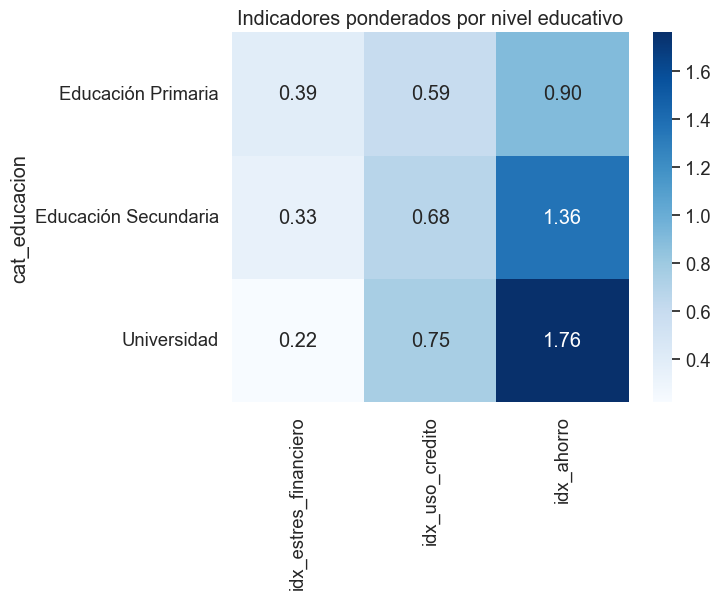

In [22]:
heat_data = pivot_educ_w.set_index("cat_educacion")[
    ["idx_estres_financiero", "idx_uso_credito", "idx_ahorro"]
]

sns.heatmap(
    heat_data,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Indicadores ponderados por nivel educativo")
plt.show()

In [23]:
pivot_laboral_w = make_weighted_pivot(work, "estado_laboral", "weight")
display(pivot_laboral_w)

,estado_laboral,idx_estres_financiero,idx_uso_credito,idx_ahorro,N_muestral,N_ponderado
0,Asalariado,0.299,0.877,1.496,3733,1.632615e+07
1,Autónomo,0.326,0.814,1.582,844,3.566395e+06
2,Desempleado,0.527,0.504,0.950,780,3.836572e+06
3,Jubilado,0.215,0.401,1.105,1060,5.536234e+06
4,Otros inactivos,0.326,0.344,1.020,1137,5.783699e+06


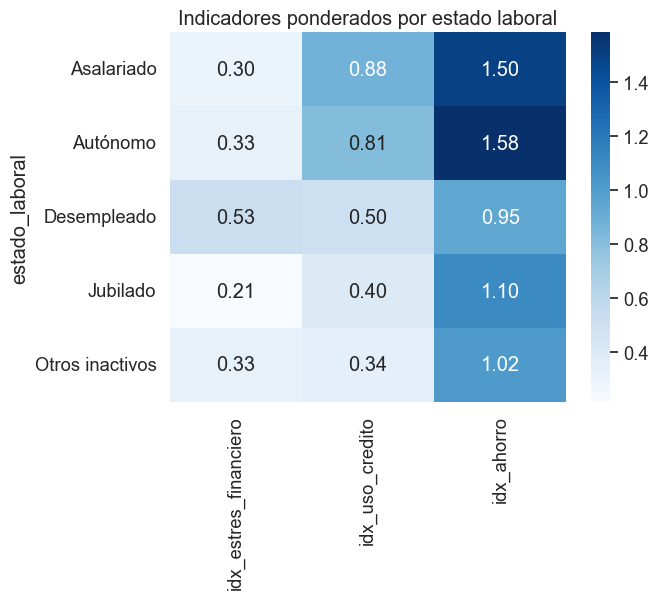

In [24]:
heat_data = pivot_laboral_w.set_index("estado_laboral")[
    ["idx_estres_financiero", "idx_uso_credito", "idx_ahorro"]
]

sns.heatmap(
    heat_data,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Indicadores ponderados por estado laboral")
plt.show()

In [25]:
pivot_familia_w = make_weighted_pivot(work, "familia", "weight")
display(pivot_familia_w)

,familia,idx_estres_financiero,idx_uso_credito,idx_ahorro,N_muestral,N_ponderado
0,Otros adultos,0.318,0.397,1.212,1787,8.037777e+06
1,Vive con pareja,0.320,0.775,1.335,4812,2.259480e+07
2,Vive solo,0.309,0.604,1.320,955,4.416471e+06


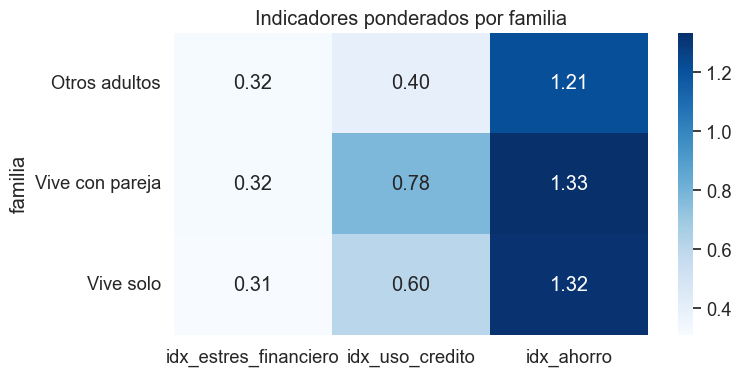

In [26]:
heat_data = pivot_familia_w.set_index("familia")[
    ["idx_estres_financiero", "idx_uso_credito", "idx_ahorro"]
]

plt.figure(figsize=(8,4))

ax = sns.heatmap(
    heat_data,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Indicadores ponderados por familia")

# Y horizontal
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()


In [27]:
pivot_inmob_w = make_weighted_pivot(work, "riq_inmob", "weight")
display(pivot_inmob_w)

,riq_inmob,idx_estres_financiero,idx_uso_credito,idx_ahorro,N_muestral,N_ponderado
0,No posee residencia principal,0.488,0.608,1.125,1748,8.730344e+06
1,Residencia principal y otras,0.214,0.626,1.546,2847,1.221191e+07
2,Solo residencia principal,0.303,0.739,1.207,2959,1.410679e+07


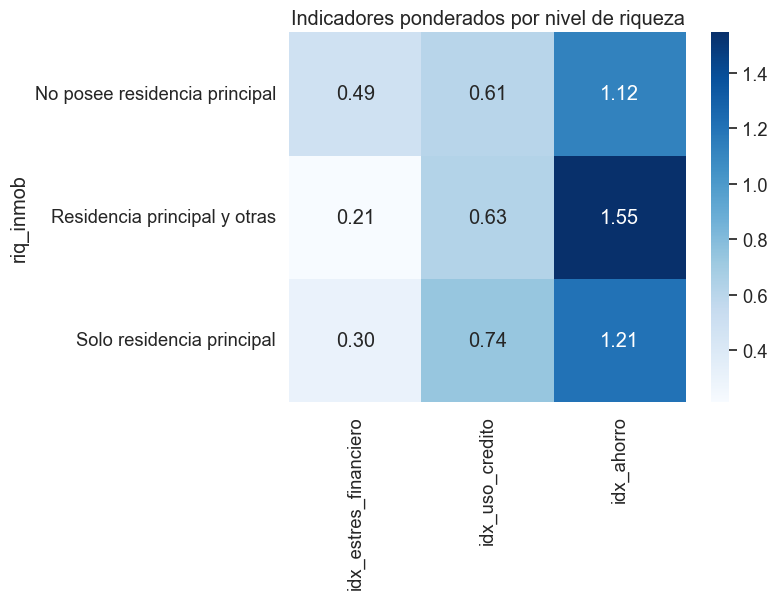

In [28]:
heat_data = pivot_inmob_w.set_index("riq_inmob")[
    ["idx_estres_financiero", "idx_uso_credito", "idx_ahorro"]
]

sns.heatmap(
    heat_data,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Indicadores ponderados por nivel de riqueza")
plt.show()

### 3.6. Tests estadísticos sin ponderar



Kruskal–Wallis 
Pq Variables son:

- Suma de estrategias binarias
- Variable discreta
- Sin distribución normal y a menudo asimétrica (0 > 1 o al reves, casi nunca son iguales)

H0: Las distribuciones de idx_estres_financiero, idx_uso_credito, idx_ahorro son las mismas en todos los grupos estado_laboral.
H1: Al menos un grupo es diferente.

In [29]:

for idx in ["idx_estres_financiero", "idx_uso_credito", "idx_ahorro"]:
    groups = [
        work.loc[work["estado_laboral"] == g, idx]
        for g in work["estado_laboral"].dropna().unique()
    ]
    stat, p = kruskal(*groups)
    print(f"{idx}: p-value = {p}")


idx_estres_financiero: p-value = 1.7984267172869473e-29
idx_uso_credito: p-value = 1.570609899051382e-138
idx_ahorro: p-value = 4.133913719725067e-92


Conclusion H1: todos los diferentes 

H0: Las distribuciones de idx_estres_financiero, idx_uso_credito, idx_ahorro son las mismas en todos los grupos de nivel educativo.
H1: Al menos un grupo es diferente.

In [30]:

for idx in ["idx_estres_financiero", "idx_uso_credito", "idx_ahorro"]:
    groups = [
        work.loc[work["cat_educacion"] == g, idx]
        for g in work["cat_educacion"].dropna().unique()
    ]
    stat, p = kruskal(*groups)
    print(f"{idx}: p-value = {p}")



idx_estres_financiero: p-value = 2.6247596562693138e-34
idx_uso_credito: p-value = 3.5937151699425405e-13
idx_ahorro: p-value = 5.538073180568106e-220


Conclusion H1: todos los diferentes 

H0: Las distribuciones de idx_estres_financiero, idx_uso_credito, idx_ahorro son las mismas en todos los grupos de estado familiar.
H1: Al menos un grupo es diferente.

In [31]:
for idx in ["idx_estres_financiero", "idx_uso_credito", "idx_ahorro"]:
    groups = [
        work.loc[work["familia"] == g, idx]
        for g in work["familia"].dropna().unique()
    ]
    stat, p = kruskal(*groups)
    print(f"{idx}: p-value = {p}")

idx_estres_financiero: p-value = 0.08352501697457403
idx_uso_credito: p-value = 2.4748763873992805e-87
idx_ahorro: p-value = 1.5737619303320957e-09


- Para idx_uso_credito y idx_ahorro todos son diferentes 
- Para idx_estres_financiero son iguales para todos grupos 

H0: Las distribuciones de idx_estres_financiero, idx_uso_credito, idx_ahorro son las mismas en todos los grupos de propiedad inmobilaria.
H1: Al menos un grupo es diferente.

In [32]:
for idx in ["idx_estres_financiero", "idx_uso_credito", "idx_ahorro"]:
    groups = [
        work.loc[work["riq_inmob"] == g, idx]
        for g in work["riq_inmob"].dropna().unique()
    ]
    stat, p = kruskal(*groups)
    print(f"{idx}: p-value = {p}")

idx_estres_financiero: p-value = 1.0316289601244227e-38
idx_uso_credito: p-value = 5.064901159357695e-19
idx_ahorro: p-value = 4.5455688002348225e-51


Conclusion H1: todos los diferentes 

### 3.7. Tests estadísticos ponderados

Modelo de regresión lineal ponderado (WLS) - La prueba estadística de Mínimos Cuadrados Ponderados (WLS, por sus siglas en inglés: Weighted Least Squares) es un método de regresión utilizado cuando los datos presentan heterocedasticidad, es decir, cuando la varianza de los residuos no es constante a lo largo de todas las observaciones. 


Categorías básicas (con que compara):
- estado_laboral → Asalariado
- edad_grupo → 18-34 años
- cat_educacion → Educación Primaria
- riq_inmob → No posee residencia principal
- familia → Otros adultos 

In [33]:
cols = ["idx_estres_financiero",'idx_ahorro','idx_uso_credito', "estado_laboral", "edad_grupo", "cat_educacion", "riq_inmob", "familia", "weight"]
work_model = work[cols].copy()

print("Rows before:", len(work_model))
work_model = work_model.dropna()
print("Rows after :", len(work_model))


Rows before: 7554
Rows after : 7554


In [34]:
work_model = work_model[work_model["weight"] > 0]

#### 3.7.1. Estrés financiero

In [35]:
model = smf.wls(
    "idx_estres_financiero ~ C(estado_laboral) + C(edad_grupo) + C(cat_educacion) + C(riq_inmob) + C(familia)",
    data=work_model,
    weights=work_model["weight"]
).fit(cov_type="HC3")   # robust SE

print(model.summary())


                              WLS Regression Results                             
Dep. Variable:     idx_estres_financiero   R-squared:                       0.052
Model:                               WLS   Adj. R-squared:                  0.050
Method:                    Least Squares   F-statistic:                     17.10
Date:                   Sun, 15 Feb 2026   Prob (F-statistic):           2.36e-42
Time:                           18:43:46   Log-Likelihood:                -7921.5
No. Observations:                   7554   AIC:                         1.587e+04
Df Residuals:                       7539   BIC:                         1.598e+04
Df Model:                             14                                         
Covariance Type:                     HC3                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------

**Conclusiones del índice estrés financiero**

El modelo explica el 5,2% de la variación del índice. 

Desempleado → +0.175 (p < 0.001) - los desempleados tienen un índice de estrés financiero 0,175 puntos más alto, en igualdad de condiciones.

Secundaria → −0.061 (p = 0.016)
Universidad → −0.163 (p < 0.001) - Los niveles más altos de educación se asocian con un menor estrés financiero. 

Residencia principal → −0.181
Residencia + otras → −0.245  - Ser propietario de una propiedad reduce significativamente el estrés financiero. 

Ningún grupo de edad es significativo.

Tras controlar los factores:

- El estrés financiero es significativamente mayor entre los desempleados
- Significativamente menor entre las personas con educación superior
- Significativamente menor entre los propietarios de vivienda
- La edad por sí sola no influye

#### 3.7.2. Uso de crédito

In [36]:
import statsmodels.formula.api as smf

model = smf.wls(
    "idx_uso_credito ~ C(estado_laboral) + C(edad_grupo) + C(cat_educacion) + C(riq_inmob) + C(familia)",
    data=work_model,
    weights=work_model["weight"]
).fit(cov_type="HC3")   # robust SE

print(model.summary())

                            WLS Regression Results                            
Dep. Variable:        idx_uso_credito   R-squared:                       0.130
Model:                            WLS   Adj. R-squared:                  0.129
Method:                 Least Squares   F-statistic:                     71.13
Date:                Sun, 15 Feb 2026   Prob (F-statistic):          8.25e-191
Time:                        18:43:46   Log-Likelihood:                -9774.8
No. Observations:                7554   AIC:                         1.958e+04
Df Residuals:                    7539   BIC:                         1.968e+04
Df Model:                          14                                         
Covariance Type:                  HC3                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

**Conclusiones del índice de uso de crédito**

El modelo explica el 13% de la variación en la utilización del crédito. Es más probable que los factores sociodemográficos expliquen el uso del crédito que el estrés. 

Desempleado → −0.297 (p < 0.001)
Jubilado → −0.183
Otros inactivos → −0.330 - Los desempleados e inactivos utilizan el crédito con mucha menos frecuencia. 

35–44 → +0.306
45–54 → +0.228
65–79 → −0.206 - La actividad crediticia alcanza su punto máximo entre los 35 y los 44 años.
Después de los 65, se produce un marcado descenso. 

Secundaria → +0.088 (significativo)
Universidad → no significativo - La educación superior no aumenta la actividad crediticia, pero la educación secundaria sí la aumenta ligeramente. 

Residencia principal → +0.166
Residencia + otras → +0.105 - Los propietarios tienen más probabilidades de utilizar crédito (Al menos hipotecas)

Vive con pareja → +0.279
Vive solo → +0.182 - Los hogares con pareja tienen mayor probabilidad de utilizar crédito. 

- El uso de credito es significativamente menor entre los desempleados e inactivos
- Significativamente mayor entre las personas con edad de 35 hasta 54
- Significativamente mayor entre las personas con educación secundaria

#### 3.7.3. Ahorro 

In [37]:
model = smf.wls(
    "idx_ahorro ~ C(estado_laboral) + C(edad_grupo) + C(cat_educacion) + C(riq_inmob) + C(familia)",
    data=work_model,
    weights=work_model["weight"]
).fit(cov_type="HC3")   # robust SE

print(model.summary())

                            WLS Regression Results                            
Dep. Variable:             idx_ahorro   R-squared:                       0.199
Model:                            WLS   Adj. R-squared:                  0.197
Method:                 Least Squares   F-statistic:                     104.3
Date:                Sun, 15 Feb 2026   Prob (F-statistic):          8.23e-277
Time:                        18:43:47   Log-Likelihood:                -10688.
No. Observations:                7554   AIC:                         2.141e+04
Df Residuals:                    7539   BIC:                         2.151e+04
Df Model:                          14                                         
Covariance Type:                  HC3                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

**Conclusiones del índice de ahorro**


El modelo explica casi el 20% de la variación en el comportamiento del ahorro. Los ahorros están mucho más fuertemente estructurados por factores sociodemográficos. 

Autónomos → +0,119 (p=0,005) - Los autónomos utilizan más instrumentos de ahorro.

Desempleados → -0,346 (efecto muy fuerte) - Los desempleados participan significativamente menos en la actividad de ahorro.

Jubilado → -0,192
Inactivos → -0,295 - Los grupos inactivos ahorran significativamente menos.

18–34 es la categoría base y tiene el nivel de índice más alto.
Todos los grupos de edad (en comparación con el grupo de 18 a 34 años) tienen una tasa de ahorro más baja. Seria conveniente comprobar a que se debe.

Secundaria → +0.421
Universidad → +0.713 - La educación superior aumenta el índice en 0,71 puntos. 

Residencia principal y otras → +0.451
Solo residencia principal → +0.164 - La propiedad y el ahorro están estrechamente relacionados. 

Vive con pareja → +0.150
Vive solo → +0.192 - Aquellos que viven solos son incluso un poco más activos a la hora de ahorrar. 



#### 3.7.4. Relación entre estrés financiero y uso credito 

In [38]:
model = smf.wls(
    "idx_uso_credito ~ idx_estres_financiero + C(estado_laboral) + C(edad_grupo) + C(cat_educacion) + C(riq_inmob) + C(familia)",
    data=work_model,
    weights=work_model["weight"]
).fit(cov_type="HC3")   # robust SE

print(model.summary())

                            WLS Regression Results                            
Dep. Variable:        idx_uso_credito   R-squared:                       0.210
Model:                            WLS   Adj. R-squared:                  0.208
Method:                 Least Squares   F-statistic:                     91.85
Date:                Sun, 15 Feb 2026   Prob (F-statistic):          9.03e-261
Time:                        18:43:47   Log-Likelihood:                -9413.4
No. Observations:                7554   AIC:                         1.886e+04
Df Residuals:                    7538   BIC:                         1.897e+04
Df Model:                          15                                         
Covariance Type:                  HC3                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

#### 3.7.5. Conclusiones de comportamiento financiero

El comportamiento de ahorro es el componente más estructurado por factores socio-demográficos, especialmente nivel educativo y patrimonio inmobiliario.
Por tanto, una estrategia de segmentación para productos de ahorro resulta coherente con las tendencias nacionales observadas. 

El uso del crédito responde principalmente al ciclo de vida y a la situación laboral.
La oferta crediticia debería adaptarse a perfiles económicamente activos y con estabilidad laboral.

El estrés financiero está fuertemente asociado al desempleo y a la baja inclusión financiera.
Antes de ofrecer productos financieros complejos, puede ser recomendable implementar programas de educación y acompañamiento financiero para estos segmentos. (Comprobar si hay correlacion entre alfabetizacion fin. y comportamiento)

### 3.8. Análisis de penetración por productos

Carga de fichero csv auxiliar de productos y creación de dataframe

In [39]:
path_prod = r"C:..\Data\ECF_auxiliar_090226.csv"


In [40]:
productos = pd.read_csv(
    path_prod,
    encoding="utf-8"
)

productos

,ID,Pension personal,Pension corporativa,Fondo inversión,Fondo inversión (extra),Acciones,Activos renta fija,Criptomonedas,Criptomonedas (extra),Hipoteca_actual,...,Tarjeta_credito_adquirida_2y,Descubierto_autorizado,Tarjeta_credito_para_efectivo,Hipoteca_flexible,Prestamo_contra_fondo_pension,Microcredito,Payday_loan,Empeño_en_casa_de_empeño,Ayuda_familia_comunidad,Prestamo_familia_comunidad
0,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,3,1,1,1,1,0,0,1,1,0,...,1,-98,-98,-98,-98,-98,-98,-98,-98,-98
3,4,1,0,0,0,0,1,0,0,1,...,0,-98,-98,-98,-98,-98,-98,-98,-98,-98
4,5,0,0,0,0,0,-98,0,0,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7759,7760,0,0,0,0,0,0,1,1,0,...,1,-98,-98,-98,-98,-98,-98,-98,-98,-98
7760,7761,0,0,1,1,0,1,0,0,0,...,1,-98,-98,-98,-98,-98,-98,-98,-98,-98
7761,7762,0,0,0,0,0,0,0,0,0,...,0,-98,-98,-98,-98,-98,-98,-98,-98,-98
7762,7763,0,0,0,0,0,-98,-98,-98,0,...,0,-98,-98,-98,-98,-98,-98,-98,-98,-98


In [41]:
productos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7764 entries, 0 to 7763
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   ID                              7764 non-null   int64
 1   Pension personal                7764 non-null   int64
 2   Pension corporativa             7764 non-null   int64
 3   Fondo inversión                 7764 non-null   int64
 4   Fondo inversión (extra)         7764 non-null   int64
 5   Acciones                        7764 non-null   int64
 6   Activos renta fija              7764 non-null   int64
 7   Criptomonedas                   7764 non-null   int64
 8   Criptomonedas (extra)           7764 non-null   int64
 9   Hipoteca_actual                 7764 non-null   int64
 10  Hipoteca_adquirida_2y           7764 non-null   int64
 11  Prestamo_personal_actual        7764 non-null   int64
 12  Prestamo_personal_adquirido_2y  7764 non-null   int64
 13  Tar

In [42]:
productos.isna().sum()

ID                                0
Pension personal                  0
Pension corporativa               0
Fondo inversión                   0
Fondo inversión (extra)           0
Acciones                          0
Activos renta fija                0
Criptomonedas                     0
Criptomonedas (extra)             0
Hipoteca_actual                   0
Hipoteca_adquirida_2y             0
Prestamo_personal_actual          0
Prestamo_personal_adquirido_2y    0
Tarjeta_credito_adquirida_2y      0
Descubierto_autorizado            0
Tarjeta_credito_para_efectivo     0
Hipoteca_flexible                 0
Prestamo_contra_fondo_pension     0
Microcredito                      0
Payday_loan                       0
Empeño_en_casa_de_empeño          0
Ayuda_familia_comunidad           0
Prestamo_familia_comunidad        0
dtype: int64

In [43]:
df_merged = work.merge(
    productos,
    on="ID",
    how="left"
)

print("Antes de merge:", df.shape)
print("Despues de merge:", df_merged.shape)


Antes de merge: (7554, 74)
Despues de merge: (7554, 96)


In [44]:
product_groups = {
    "pension_products": [
        "Pension personal",
        "Pension corporativa"
    ],
    "investment_products": [
        "Fondo inversión",
        "Fondo inversión (extra)",
        "Acciones",
        "Activos renta fija",
        "Criptomonedas",
        "Criptomonedas (extra)"
    ],
    "hipoteca": [
        "Hipoteca_actual",
        "Hipoteca_adquirida_2y",
        "Hipoteca_flexible"
    ],
    "prestamo_personal": [
        "Prestamo_personal_actual",
        "Prestamo_personal_adquirido_2y"
    ],
    "tarjeta_credito": [
        "Tarjeta_credito_adquirida_2y",
        "Tarjeta_credito_para_efectivo",
        "Descubierto_autorizado"
    ],
    "credito_alto_riesgo": [
        "Microcredito",
        "Payday_loan",
        "Prestamo_contra_fondo_pension",
        "Empeño_en_casa_de_empeño"
    ],
    "apoyo_informal": [
        "Ayuda_familia_comunidad",
        "Prestamo_familia_comunidad"
    ]
}

for new_col, cols in product_groups.items():
    df_merged[new_col] = (
        df_merged[cols]
        .sum(axis=1)
        .clip(upper=1)
    )


df_merged[["ID"] + list(product_groups.keys())].head()


,ID,pension_products,investment_products,hipoteca,prestamo_personal,tarjeta_credito,credito_alto_riesgo,apoyo_informal
0,1,0,0,1,1,0,0,0
1,2,0,0,0,1,0,0,1
2,3,1,1,-98,0,-195,-392,-196
3,4,1,1,-97,0,-196,-392,-196
4,5,0,-98,0,1,0,1,0


In [45]:
for new_col, cols in product_groups.items():
    df_merged[new_col] = (
        df_merged[cols]
        .applymap(lambda x: x if x in [0, 1] else -1)  # сначала приводим к {-1,0,1}
        .max(axis=1)  # если есть хотя бы 1 → 1; если только 0 → 0; если есть -1 и нет 1 → -1
    )

df_merged[["ID"] + list(product_groups.keys())].head()


C:\Users\anaferrandbetes\AppData\Local\Temp\ipykernel_3308\1299214383.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  .applymap(lambda x: x if x in [0, 1] else -1)  # сначала приводим к {-1,0,1}
C:\Users\anaferrandbetes\AppData\Local\Temp\ipykernel_3308\1299214383.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  .applymap(lambda x: x if x in [0, 1] else -1)  # сначала приводим к {-1,0,1}
C:\Users\anaferrandbetes\AppData\Local\Temp\ipykernel_3308\1299214383.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  .applymap(lambda x: x if x in [0, 1] else -1)  # сначала приводим к {-1,0,1}
C:\Users\anaferrandbetes\AppData\Local\Temp\ipykernel_3308\1299214383.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  .applymap(lambda x: x if x in [0, 1] else -1)  # сначала приводим к {-1,0,1}
C:\Users\anaferrandbetes\AppData\Local\Temp\ipykerne

,ID,pension_products,investment_products,hipoteca,prestamo_personal,tarjeta_credito,credito_alto_riesgo,apoyo_informal
0,1,0,0,1,1,0,0,0
1,2,0,0,0,1,0,0,1
2,3,1,1,0,0,1,-1,-1
3,4,1,1,1,0,0,-1,-1
4,5,0,0,0,1,0,1,0


In [46]:
WEIGHT_COL = "weight"
PRODUCT_COLS = [
    "pension_products",
    "investment_products",
    "hipoteca",
    "prestamo_personal",	
    "tarjeta_credito",	
    "credito_alto_riesgo",	
    "apoyo_informal"
]

In [47]:
def wmean_binary(x, w):
    m = x.notna() & w.notna()
    x = x[m].astype(float)
    w = w[m].astype(float)
    return (x * w).sum() / w.sum()


#### 3.8.1. Penetración por grupo de edad

In [48]:
age_results = []

for age in df_merged["edad_grupo"].dropna().unique():
    sub = df_merged[df_merged["edad_grupo"] == age]
    
    for p in PRODUCT_COLS:
        pen = wmean_binary(sub[p], sub[WEIGHT_COL])
        
        age_results.append({
            "edad_grupo": age,
            "product": p,
            "penetration": pen
        })

age_pen = pd.DataFrame(age_results)


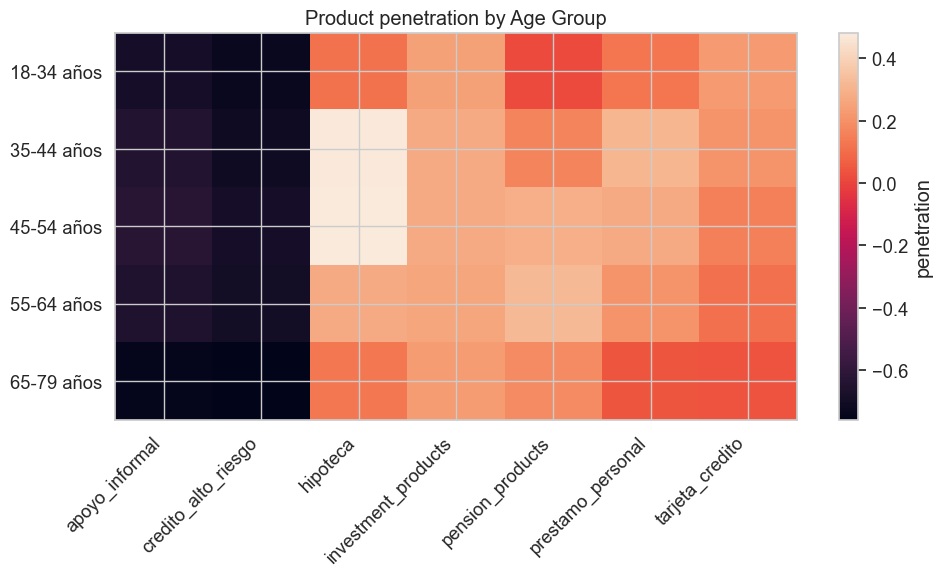

In [49]:
heat_age = age_pen.pivot(index="edad_grupo", columns="product", values="penetration")

plt.figure(figsize=(10,6))
plt.imshow(heat_age, aspect="auto")
plt.xticks(range(len(heat_age.columns)), heat_age.columns, rotation=45, ha="right")
plt.yticks(range(len(heat_age.index)), heat_age.index)
plt.colorbar(label="penetration")
plt.title("Product penetration by Age Group")
plt.tight_layout()
plt.show()


**18–34:**

- Menos hipotecas
- Productos con mayor riesgo
- Tarjetas y préstamos moderados

Potencial para productos a largo plazo.

**35–54:**

- Máximo de hipotecas
- Máximo de préstamos
- Inversiones activas

Este es el segmento bancario principal.

**65–79:**

- Préstamos bajos
- Ahorro moderado

Segmento conservador.

#### 3.8.2. Penetración por Educación

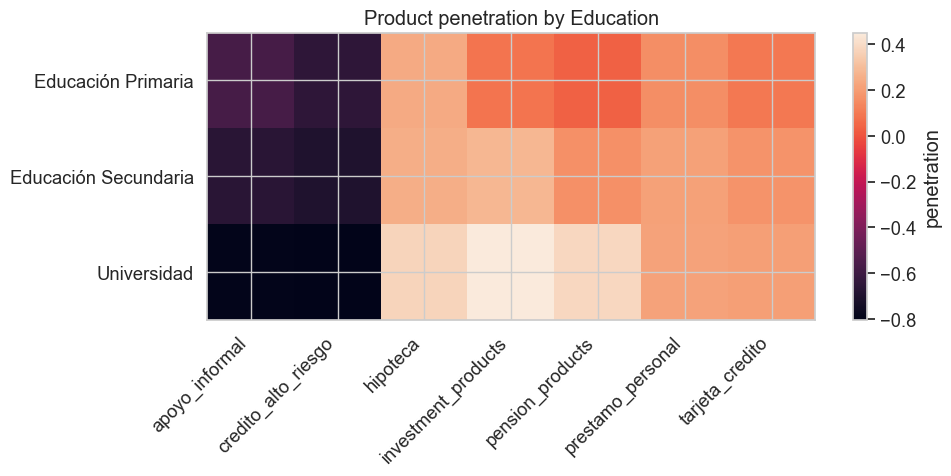

In [50]:
edu_results = []

for edu in df_merged["cat_educacion"].dropna().unique():
    sub = df_merged[df_merged["cat_educacion"] == edu]
    
    for p in PRODUCT_COLS:
        pen = wmean_binary(sub[p], sub[WEIGHT_COL])
        
        edu_results.append({
            "cat_educacion": edu,
            "product": p,
            "penetration": pen
        })

edu_pen = pd.DataFrame(edu_results)

heat_edu = edu_pen.pivot(index="cat_educacion", columns="product", values="penetration")

plt.figure(figsize=(10,5))
plt.imshow(heat_edu, aspect="auto")
plt.xticks(range(len(heat_edu.columns)), heat_edu.columns, rotation=45, ha="right")
plt.yticks(range(len(heat_edu.index)), heat_edu.index)
plt.colorbar(label="penetration")
plt.title("Product penetration by Education")
plt.tight_layout()
plt.show()


Universidad:

- Inversión máxima
- Pensión máxima
- Crédito informal mínimo

Este es el segmento de riqueza.

#### 3.8.3. Penetración por comportamiente del cliente
- High Savers
- High Credit
- High Vulnerable

In [51]:
df_merged["seg_behavior"] = np.select(
    [
        df_merged["idx_ahorro"] > df_merged["idx_ahorro"].median(),
        df_merged["idx_uso_credito"] > df_merged["idx_uso_credito"].median(),
        df_merged["idx_estres_financiero"] > df_merged["idx_estres_financiero"].median()
    ],
    [
        "High Savers",
        "High Credit",
        "High Vulnerable"
    ],
    default="Neutral"
)


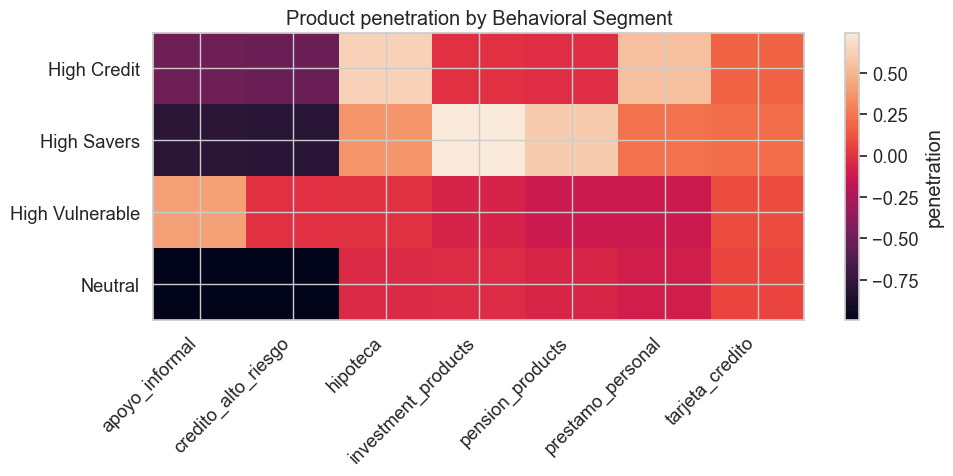

In [52]:
beh_results = []

for seg in df_merged["seg_behavior"].unique():
    sub = df_merged[df_merged["seg_behavior"] == seg]
    
    for p in PRODUCT_COLS:
        pen = wmean_binary(sub[p], sub[WEIGHT_COL])
        
        beh_results.append({
            "segment": seg,
            "product": p,
            "penetration": pen
        })

beh_pen = pd.DataFrame(beh_results)

heat_beh = beh_pen.pivot(index="segment", columns="product", values="penetration")

plt.figure(figsize=(10,5))
plt.imshow(heat_beh, aspect="auto")
plt.xticks(range(len(heat_beh.columns)), heat_beh.columns, rotation=45, ha="right")
plt.yticks(range(len(heat_beh.index)), heat_beh.index)
plt.colorbar(label="penetration")
plt.title("Product penetration by Behavioral Segment")
plt.tight_layout()
plt.show()


**Altos ahorradores:**

- Pensión máxima
- Inversión máxima
- Préstamo moderado

Este es el segmento premium a largo plazo.

**Crédito alto:**

- Hipotecas máximas
- Préstamo personal máximo
- Esta es una estrategia crediticia.

**Altamente vulnerables:**

- Máximo apoyo informal
- Sin inversión
- Pensión baja

Este es el segmento de riesgo.

**Neutral (No utilizan nada, no son activos en nada):**

- Valores promedio para todos
- Baja participación

Este es un segmento masivo sin una estrategia clara.

#### 3.8.4. Propuestas de negocio según el análisis de penetración

##### 1. Estrategia de Expansión Patrimonial
Objetivo: Grandes Ahorradores + Universitarios.
Productos: Productos de inversión, planes de pensiones, servicios de asesoría patrimonial.
Justificación: Este segmento muestra una alta propensión al ahorro y ya utiliza productos financieros a largo plazo, lo que lo hace adecuado para ofertas premium y orientadas a la inversión.

##### 2. Estrategia de Optimización Crediticia
Objetivo: Grupo de edad de 35 a 54 años + Segmento de Alto Crédito.
Productos: Hipotecas, soluciones de refinanciación, seguros relacionados con el crédito.
Justificación: Este segmento muestra la mayor actividad crediticia y se encuentra en una etapa de la vida relacionada con la vivienda, la familia y grandes compromisos financieros, lo que lo hace óptimo para estrategias de crédito estructurado.

##### 3. Estrategia de Resiliencia Financiera
Objetivo: Segmento de Alta Vulnerabilidad.
Productos: Productos de microahorro, seguros de protección de ingresos, cuentas de depósito de bajo riesgo.
Justificación: Este grupo muestra una mayor dependencia de los mecanismos de crédito informales y del estrés financiero, lo que indica la necesidad de productos de estabilización y mitigación de riesgos en lugar de instrumentos financieros de alto riesgo.

##### 4. Estrategia de Activación
Objetivo: Segmento neutral.
Productos: cuentas de ahorro básicas, soluciones de banca digital, programas de participación basados ​​en la educación financiera.
Justificación: Este segmento muestra una baja participación financiera en general, lo que representa un potencial sin explotar que puede activarse mediante productos financieros sencillos, accesibles y digitales.

## 4. Indicador de vulnerabilidad

- Uso de préstamos para cubrir gastos
- Morosidad
- Denegaciones de préstamos
- Uso de ahorros para cubrir gastos básicos.


Este indicador permite aproximar situaciones de tensión financiera estructural.


In [53]:
resumen_vuln = pd.DataFrame({
    "conteo": df["vulnerabilidad"].value_counts().sort_index(),
    "proporcion": df["vulnerabilidad"].value_counts(normalize=True).sort_index()
})

resumen_vuln.round(3)


,conteo,proporcion
vulnerabilidad,,
0,5780,0.765
1,1774,0.235


### 4.1 Vulnerabilidad por nivel educativo

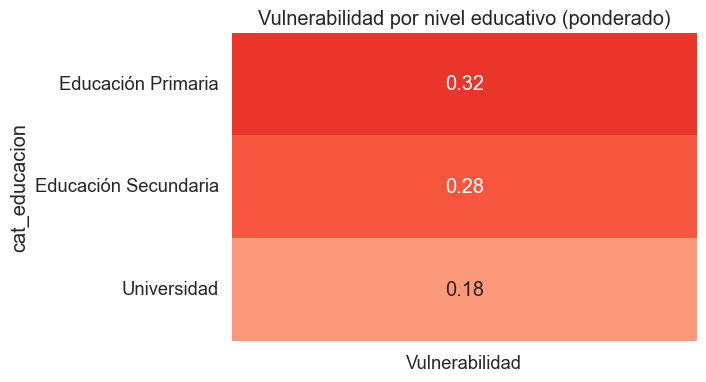

In [54]:
tabla_edu = pd.crosstab(
    df["cat_educacion"],
    df["vulnerabilidad"],
    values=df["weight"],
    aggfunc="sum",
    normalize="index"
)[1]

tabla_edu = tabla_edu.to_frame(name="Vulnerabilidad")

plt.figure(figsize=(6,4))
sns.heatmap(
    tabla_edu,
    annot=True,
    cmap="Reds",
    vmin=0,
    vmax=0.5,
    cbar=False
)

plt.title("Vulnerabilidad por nivel educativo (ponderado)")
plt.show()


### 4.2. Vulnerabilidad por situación laboral

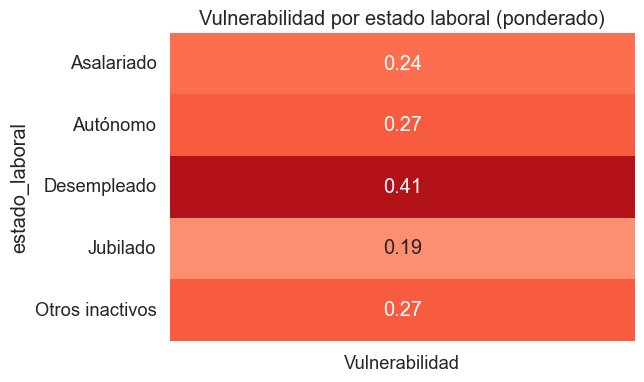

In [55]:
tabla_lab = pd.crosstab(
    df["estado_laboral"],
    df["vulnerabilidad"],
    values=df["weight"],
    aggfunc="sum",
    normalize="index"
)[1]

tabla_lab = tabla_lab.to_frame(name="Vulnerabilidad")

plt.figure(figsize=(6,4))
sns.heatmap(
    tabla_lab,
    annot=True,
    cmap="Reds",
    vmin=0,
    vmax=0.5,
    cbar=False
)

plt.title("Vulnerabilidad por estado laboral (ponderado)")
plt.show()


### 4.3. Vulnerabilidad por tipo de unidad familiar


In [56]:
pd.crosstab(
    df["familia"],
    df["vulnerabilidad"],
    values=df["weight"],
    aggfunc="sum",
    normalize="index"
).round(2)


vulnerabilidad,0,1
familia,,
Otros adultos,0.74,0.26
Vive con pareja,0.74,0.26
Vive solo,0.74,0.26


### 4.4. Vulnerabilidad por edad

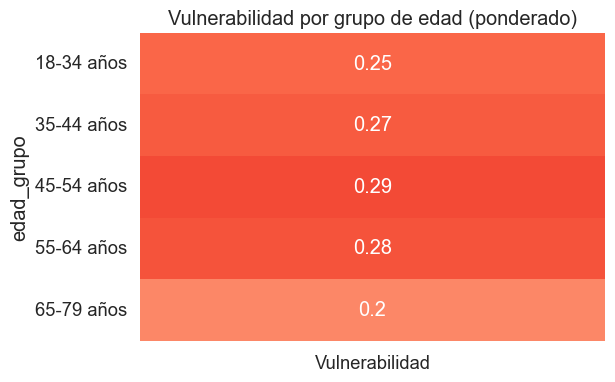

In [57]:
tabla_age = pd.crosstab(
    work["edad_grupo"],
    df["vulnerabilidad"],
    values=df["weight"],
    aggfunc="sum",
    normalize="index"
)[1]

tabla_age = tabla_age.to_frame(name="Vulnerabilidad")

plt.figure(figsize=(6,4))
sns.heatmap(
    tabla_age,
    annot=True,
    cmap="Reds",
    vmin=0,
    vmax=0.5,
    cbar=False
)

plt.title("Vulnerabilidad por grupo de edad (ponderado)")
plt.show()


### 4.5. Vulnerabilidad por Competencia financiera

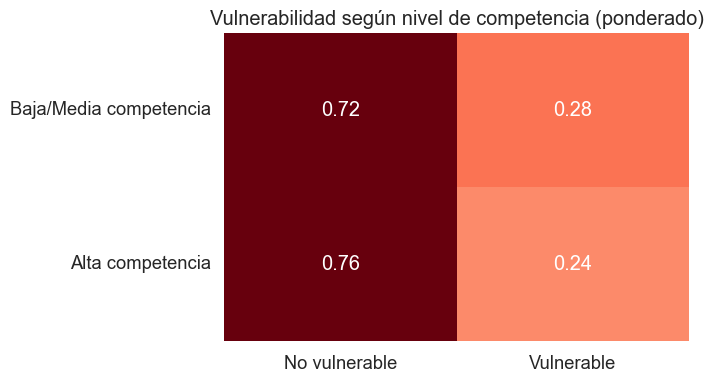

In [58]:
tabla_comp_vuln = pd.crosstab(
    df["comp_fin_bin"],
    df["vulnerabilidad"],
    values=df["weight"],
    aggfunc="sum",
    normalize="index"
)

tabla_comp_vuln.index = ["Baja/Media competencia", "Alta competencia"]
tabla_comp_vuln.columns = ["No vulnerable", "Vulnerable"]

plt.figure(figsize=(6,4))
sns.heatmap(
    tabla_comp_vuln,
    annot=True,
    cmap="Reds",
    vmin=0,
    vmax=0.6,
    cbar=False
)

plt.title("Vulnerabilidad según nivel de competencia (ponderado)")
plt.show()


### 4.6. Test Estadístico - Modelo GLM (Generalized Linear Model)

In [59]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model_vuln = smf.glm(
    "vulnerabilidad ~ comp_fin_bin + C(estado_laboral) + C(edad_grupo) + C(cat_educacion) + C(riq_inmob) + C(familia)",
    data=df,
    family=sm.families.Binomial(),
    freq_weights=df["weight"]
).fit(cov_type="HC3")

print(model_vuln.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:         vulnerabilidad   No. Observations:                 7554
Model:                            GLM   Df Residuals:              35049032.93
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.9032e+07
Date:                Sun, 15 Feb 2026   Deviance:                   3.8064e+07
Time:                        18:43:52   Pearson chi2:                 3.52e+07
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:                  HC3                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

Odds Ratios 

In [60]:
import numpy as np

params = model_vuln.params
conf = model_vuln.conf_int()

odds = np.exp(params)
conf_odds = np.exp(conf)

results = pd.DataFrame({
    "OR": odds,
    "CI_low": conf_odds[0],
    "CI_high": conf_odds[1],
    "p_value": model_vuln.pvalues
})

results


,OR,CI_low,CI_high,p_value
Intercept,0.670957,0.669061,0.672858,0.000000e+00
C(estado_laboral)[T.Autónomo],1.124277,1.121258,1.127304,0.000000e+00
C(estado_laboral)[T.Desempleado],1.827081,1.822622,1.831550,0.000000e+00
C(estado_laboral)[T.Jubilado],0.883357,0.880083,0.886644,0.000000e+00
C(estado_laboral)[T.Otros inactivos],1.107831,1.105025,1.110644,0.000000e+00
C(edad_grupo)[T.35-44 años],1.095130,1.092179,1.098088,0.000000e+00
C(edad_grupo)[T.45-54 años],1.273047,1.269741,1.276360,0.000000e+00
C(edad_grupo)[T.55-64 años],1.171622,1.168440,1.174813,0.000000e+00
C(edad_grupo)[T.65-79 años],0.886286,0.882919,0.889667,0.000000e+00
C(cat_educacion)[T.Educación Secundaria],0.790309,0.788695,0.791925,0.000000e+00


Pseudo-R²

In [61]:
llf = model_vuln.llf
llnull = model_vuln.null_deviance / -2

pseudo_r2 = 1 - (llf / llnull)
pseudo_r2


np.float64(0.05391829710333251)

Efectos marginales

In [62]:
marg = model_vuln.get_margeff()
print(marg.summary())


         GLM Marginal Effects        
Dep. Variable:         vulnerabilidad
Method:                          dydx
At:                           overall
                                                  dy/dx    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
C(estado_laboral)[T.Autónomo]                    0.0205      0.000     85.380      0.000       0.020       0.021
C(estado_laboral)[T.Desempleado]                 0.1053      0.000    488.332      0.000       0.105       0.106
C(estado_laboral)[T.Jubilado]                   -0.0217      0.000    -65.484      0.000      -0.022      -0.021
C(estado_laboral)[T.Otros inactivos]             0.0179      0.000     79.146      0.000       0.017       0.018
C(edad_grupo)[T.35-44 años]                      0.0159      0.000     66.025      0.000       0.015       0.016
C(edad_grupo)[T.45-54 años]                      0.0422  

c:\Users\anaferrandbetes\anaconda3\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:2381: UserWarning: weights are not taken into account by margeff
  warnings.warn("weights are not taken into account by margeff")


Comparación de AIC (Akaike Information Criterion)

In [63]:
model_no_comp = smf.glm(
    "vulnerabilidad ~ C(estado_laboral) + C(edad_grupo) + C(cat_educacion) + C(riq_inmob) + C(familia)",
    data=df,
    family=sm.families.Binomial(),
    freq_weights=df["weight"]
).fit(cov_type="HC3")

model_no_comp.aic, model_vuln.aic


(np.float64(38065940.90597799), np.float64(38064380.5601244))

#### Interpretación del modelo de vulnerabilidad

- La competencia financiera presenta un efecto negativo y significativo sobre la vulnerabilidad (OR = 0.968, p < 0.001).
- El efecto marginal es reducido: disminuye la probabilidad de vulnerabilidad en aproximadamente −0.6 puntos porcentuales.
- El pseudo R² del modelo es moderado (≈ 0.054), lo que indica que la vulnerabilidad depende principalmente de factores estructurales.

Factores con mayor impacto:

- Desempleo: OR = 1.83 → fuerte aumento del riesgo.
- Educación universitaria: OR = 0.46 → fuerte reducción del riesgo.
- Propiedad inmobiliaria múltiple: OR = 0.41 → importante efecto protector.

Comparación de modelos:
- El modelo con competencia mejora ligeramente el AIC respecto al modelo sin competencia.
- Sin embargo, la mejora es pequeña, lo que confirma que la competencia financiera tiene un impacto limitado frente a variables socioeconómicas.

**Conclusión:**

La vulnerabilidad financiera está determinada principalmente por condiciones estructurales (empleo, educación y riqueza), mientras que la competencia financiera aporta un efecto adicional pero de magnitud reducida.


## 5. Análisis de brechas estructurales y oportunidades de negocio

In [64]:
# Check de df_brechas, comprobar distribución de actividad_score, complejidad, comp_prod, vulnerabilidad
df[["actividad_score","actividad","complejidad","comp_prod","vulnerabilidad"]].mean()

actividad_score    2.065131
actividad          0.532301
complejidad        0.693805
comp_prod          0.741594
vulnerabilidad     0.234842
dtype: float64

### 5.1. Creación de brechas estructurales

#### 5.1.1. Demanda insatisfecha
Alta competencia financiera + baja competencia de producto
→ saben, pero no usan productos


In [65]:
brecha1 = df[(df.comp_fin_bin == 1) & (df.comp_prod == 0)]

#### 5.1.2. Productos demasiado complejos
Baja competencia financiera + productos complejos
→ riesgo de desajuste


In [66]:
brecha2 = df[(df.comp_fin_bin == 0) & (df.complejidad == 1)]

#### 5.1.3. Vulnerables inactivos
Alta vulnerabilidad + baja actividad
→ necesitan protección, productos simples


In [67]:
brecha3 = df[(df.vulnerabilidad == 1) & (df.actividad == 0)]

#### 5.1.4. Mercado dinámico
Alta actividad financiera
→ potencial para nuevas ofertas



In [68]:
brecha4 = df[df.actividad == 1]

#### 5.3.5. Resumen de brechas
Brecha 1 — Demanda insatisfecha
Personas con conocimiento pero sin uso → oportunidad de activación.

Brecha 2 — Productos demasiado complejos
Personas con baja competencia financiera usando productos complejos → riesgo.

Brecha 3 — Vulnerables inactivos
Personas vulnerables que no se mueven → necesitan productos simples, seguros, acompañamiento.

Brecha 4 — Mercado dinámico
Personas activas → potencial para innovación, cross‑selling, productos avanzados.

In [69]:
resumen = pd.DataFrame({
    "Brecha": ["Demanda insatisfecha", "Productos complejos", "Vulnerables inactivos", "Mercado dinámico"],
    "N casos": [len(brecha1), len(brecha2), len(brecha3), len(brecha4)],
    "% población": [len(brecha1)/len(df)*100,
                    len(brecha2)/len(df)*100,
                    len(brecha3)/len(df)*100,
                    len(brecha4)/len(df)*100]
})

### 5.3. Perfil demográfico de cada brecha

#### 5.3.1 Educación

In [70]:
for i, brecha in enumerate([brecha1, brecha2, brecha3, brecha4], start=1):
    print(f"\nBrecha {i} - cat_educacion")
    print(brecha["cat_educacion"].value_counts(normalize=True).round(3))


Brecha 1 - cat_educacion
cat_educacion
Universidad             0.365
Educación Secundaria    0.329
Educación Primaria      0.305
Name: proportion, dtype: float64

Brecha 2 - cat_educacion
cat_educacion
Educación Primaria      0.414
Universidad             0.339
Educación Secundaria    0.247
Name: proportion, dtype: float64

Brecha 3 - cat_educacion
cat_educacion
Educación Primaria      0.578
Educación Secundaria    0.257
Universidad             0.164
Name: proportion, dtype: float64

Brecha 4 - cat_educacion
cat_educacion
Universidad             0.509
Educación Primaria      0.259
Educación Secundaria    0.232
Name: proportion, dtype: float64


**Conclusión sobre educación**

**Brecha 1 – Demanda insatisfecha**
(Alta competencia financiera, baja competencia de producto)
- Universidad: 36.5%
- Secundaria: 32.9%
- Primaria: 30.5%
Es una brecha de personas relativamente formadas, con más estudios que la media.
Tienen conocimiento, pero no usan productos.

**Brecha 2 – Productos demasiado complejos**
(Baja competencia financiera, productos complejos)
- Primaria: 41.4%
- Universidad: 33.9%
- Secundaria: 24.7%
Aquí aparece un patrón claro:
Las personas con menor educación están usando productos complejos sin tener competencia financiera.
Es un grupo de riesgo.

**Brecha 3 – Vulnerables inactivos**
(Alta vulnerabilidad, baja actividad)
- Primaria: 57.8%
- Secundaria: 25.7%
- Universidad: 16.4%
Este es el grupo más vulnerable y con menor educación.
Claramente un segmento desfavorecido.

**Brecha 4 – Mercado dinámico**
(Alta actividad financiera)
- Universidad: 50.9%
- Primaria: 25.9%
- Secundaria: 23.2%
Este es el grupo más formado y más activo.
Son los que más usan productos financieros









#### 5.3.2. Edad

In [71]:
for i, brecha in enumerate([brecha1, brecha2, brecha3, brecha4], start=1):
    print(f"\nBrecha {i} - edad_grupo")
    print(brecha["edad_grupo"].value_counts(normalize=True).round(3))


Brecha 1 - edad_grupo
edad_grupo
18-34 años    0.427
65-79 años    0.159
55-64 años    0.153
45-54 años    0.137
35-44 años    0.123
Name: proportion, dtype: float64

Brecha 2 - edad_grupo
edad_grupo
45-54 años    0.257
35-44 años    0.244
18-34 años    0.184
55-64 años    0.182
65-79 años    0.132
Name: proportion, dtype: float64

Brecha 3 - edad_grupo
edad_grupo
18-34 años    0.297
45-54 años    0.210
55-64 años    0.185
65-79 años    0.176
35-44 años    0.132
Name: proportion, dtype: float64

Brecha 4 - edad_grupo
edad_grupo
45-54 años    0.275
35-44 años    0.219
55-64 años    0.203
18-34 años    0.190
65-79 años    0.113
Name: proportion, dtype: float64


**Conclusión por Edad**

**Brecha 1 – Demanda insatisfecha**
- Muy jóvenes (18–34): 42.7%

Jóvenes con conocimiento pero sin uso → falta de experiencia o barreras de entrada.

**Brecha 2 – Productos complejos**
- 45–54: 25.7%
- 35–44: 24.4%

Adultos de mediana edad usando productos complejos sin suficiente competencia → riesgo financiero

**Brecha 3 – Vulnerables inactivos**
- 18–34: 29.7%
- 45–54: 21.0%

Jóvenes y adultos vulnerables que no participan → riesgo social

**Brecha 4 – Mercado dinámico**
- 45–54: 27.5%
- 35–44: 21.9%

Usuarios maduros, económicamente activos


#### 5.3.3 Situación laboral

In [72]:
for i, brecha in enumerate([brecha1, brecha2, brecha3, brecha4], start=1):
    print(f"\nBrecha {i} - estado_laboral")
    print(brecha["estado_laboral"].value_counts(normalize=True).round(3))


Brecha 1 - estado_laboral
estado_laboral
Asalariado         0.372
Otros inactivos    0.258
Jubilado           0.167
Desempleado        0.134
Autónomo           0.069
Name: proportion, dtype: float64

Brecha 2 - estado_laboral
estado_laboral
Asalariado         0.531
Otros inactivos    0.130
Autónomo           0.126
Jubilado           0.111
Desempleado        0.102
Name: proportion, dtype: float64

Brecha 3 - estado_laboral
estado_laboral
Asalariado         0.302
Desempleado        0.244
Otros inactivos    0.234
Jubilado           0.132
Autónomo           0.087
Name: proportion, dtype: float64

Brecha 4 - estado_laboral
estado_laboral
Asalariado         0.583
Autónomo           0.137
Jubilado           0.110
Otros inactivos    0.095
Desempleado        0.075
Name: proportion, dtype: float64


**Conclusión por estado laboral**

**Brecha 1 - Demanda insatisfecha**
- Asalariados: 37%
- Inactivos: 26%

Personas integradas laboralmente pero sin uso de productos

**Brecha 2 - Productos demasiado complejos**
- Asalariados: 53%

Mucha gente con empleo estable usando productos complejos sin suficiente competencia → riesgo de sobreendeudamiento.

**Brecha 3 - Vulnerables inactivos**
- Desempleados: 24%
- Inactivos: 23%

Vulnerabilidad concentrada en personas fuera del mercado laboral

**Brecha 4 - Mercado dinámico**
- Asalariados: 58%
- Autónomos: 14%

Usuarios activos y económicamente integrados


#### 5.3.4 Riqueza inmobiliaria

In [73]:
for i, brecha in enumerate([brecha1, brecha2, brecha3, brecha4], start=1):
    print(f"\nBrecha {i} - riq_inmob")
    print(brecha["riq_inmob"].value_counts(normalize=True).round(3))


Brecha 1 - riq_inmob
riq_inmob
Solo residencia principal        0.370
Residencia principal y otras     0.347
No posee residencia principal    0.283
Name: proportion, dtype: float64

Brecha 2 - riq_inmob
riq_inmob
Solo residencia principal        0.428
Residencia principal y otras     0.346
No posee residencia principal    0.227
Name: proportion, dtype: float64

Brecha 3 - riq_inmob
riq_inmob
No posee residencia principal    0.427
Solo residencia principal        0.352
Residencia principal y otras     0.221
Name: proportion, dtype: float64

Brecha 4 - riq_inmob
riq_inmob
Residencia principal y otras     0.411
Solo residencia principal        0.387
No posee residencia principal    0.202
Name: proportion, dtype: float64


**Conclusión por riqueza inmobiliaria**

**Brecha 1 - Demanda insatisfecha**
- Solo residencia principal: 37%
- No posee vivienda: 28%

Clase media baja, con cierta estabilidad

**Brecha 2 - Productos demasiado complejos**
- Solo residencia principal: 43%

Hogares con vivienda en propiedad pero sin capacidad para gestionar productos complejos


**Brecha 3 - Vulnerables inactivos**
- No posee vivienda: 43%

Claramente el grupo más vulnerable


**Brecha 4 - Mercado dinámico**
- Residencia principal + otras: 41%

Hogares con patrimonio → usuarios avanzados


### 5.4. Visualizaciones

#### 5.4.1. Distribución de brechas
Gráfico de barras
Es la visualización más importante de todo el análisis.
Te permite mostrar:
- qué brecha es más grande
- cuál es marginal
- dónde está el mayor potencial o riesgo


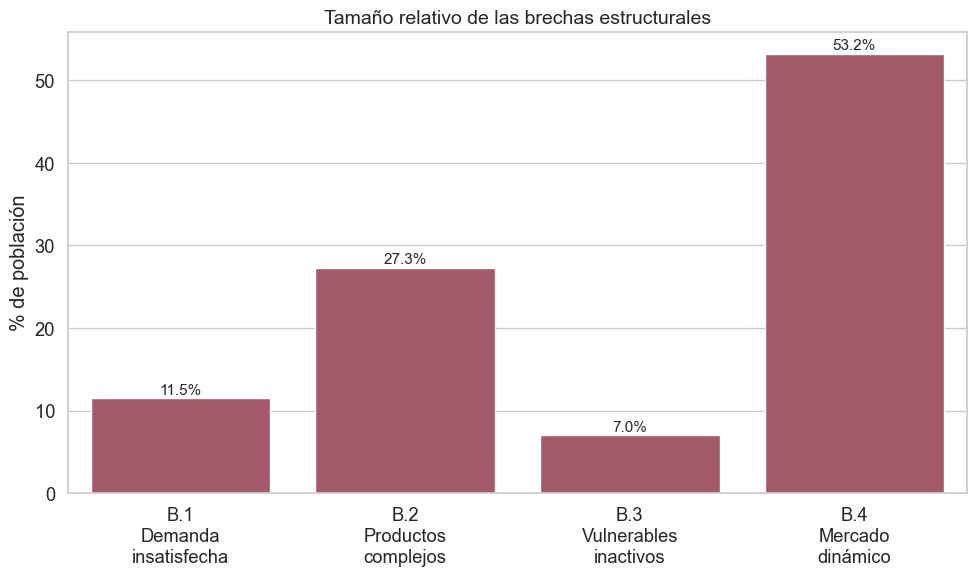

In [74]:
plt.figure(figsize=(10, 6))

resumen["Brecha_label"] = [
    "B.1\nDemanda\ninsatisfecha",
    "B.2\nProductos\ncomplejos",
    "B.3\nVulnerables\ninactivos",
    "B.4\nMercado\ndinámico"
]

ax = sns.barplot(
    data=resumen,
    x="Brecha_label",
    y="% población",
    color="#B04C65"
)

# Añadir etiquetas encima de cada barra
for i, v in enumerate(resumen["% población"]):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=11)

plt.title("Tamaño relativo de las brechas estructurales", fontsize=14)
plt.ylabel("% de población")
plt.xlabel("")
plt.tight_layout()
plt.show()

#### 5.4.2. Competencia financiera vs competencia de producto
Heatmap 2×2
Este gráfico es oro puro porque visualiza:
- demanda insatisfecha
- riesgo por productos complejos
- usuarios avanzados
- usuarios desconectados


#### 5.4.3. Actividad vs vulnerabilidad
Heatmap 2×2
Este es clave para identificar:
- vulnerables inactivos
- vulnerables activos
- no vulnerables activos
- no vulnerables inactivos


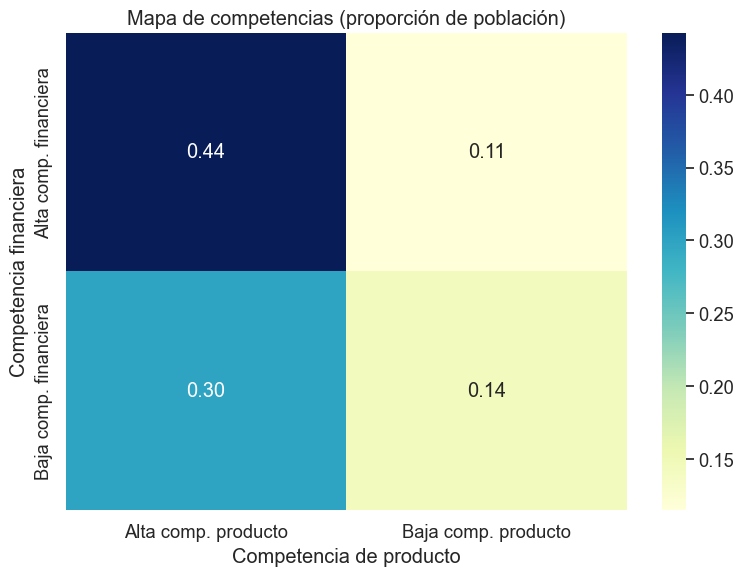

In [75]:
# Tabla con etiquetas claras
tabla = pd.crosstab(
    df.comp_fin_bin.replace({0: "Baja comp. financiera", 1: "Alta comp. financiera"}),
    df.comp_prod.replace({0: "Baja comp. producto", 1: "Alta comp. producto"}),
    normalize="all"
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    tabla,
    annot=True,
    cmap="YlGnBu",   # mezcla verde-azul
    fmt=".2f"
)

plt.xlabel("Competencia de producto")
plt.ylabel("Competencia financiera")
plt.title("Mapa de competencias (proporción de población)")
plt.tight_layout()
plt.show()

#### 5.4.4. Complejidad de productos por competencia financiera
Gráfico de barras apiladas
Sirve para mostrar si la gente con baja competencia financiera está usando productos complejos (brecha 2).


<Figure size 1000x600 with 0 Axes>

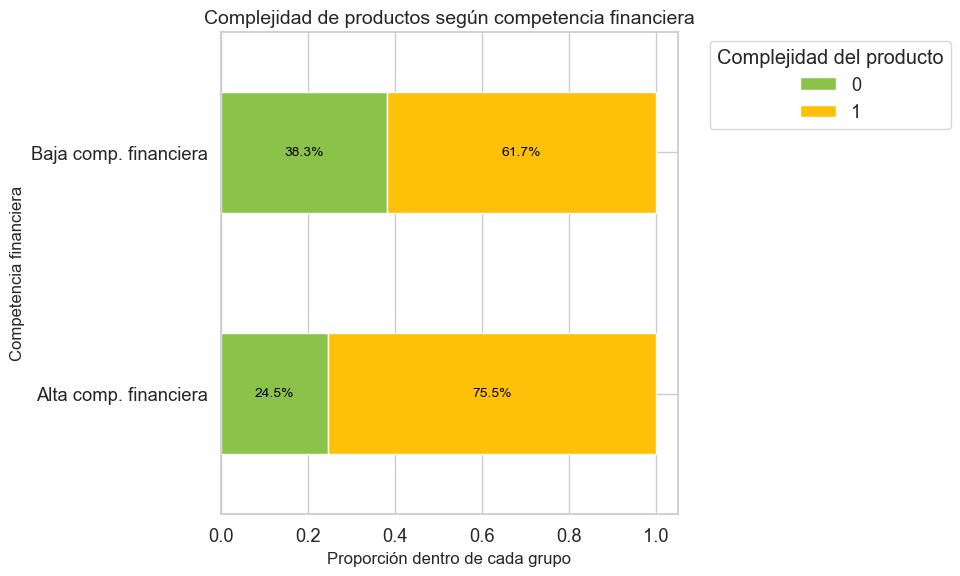

In [76]:
# Tabla con etiquetas claras
tabla = pd.crosstab(
    df.comp_fin_bin.replace({0: "Baja comp. financiera", 1: "Alta comp. financiera"}),
    df.complejidad,
    normalize="index"
)

plt.figure(figsize=(10, 6))

# Colores más visibles (verde → naranja → rojo)
colores = ["#8BC34A", "#FFC107", "#F44336"]  # verde, amarillo, rojo

ax = tabla.plot(
    kind="barh",
    stacked=True,
    color=colores,
    figsize=(10, 6)
)

plt.title("Complejidad de productos según competencia financiera", fontsize=14)
plt.xlabel("Proporción dentro de cada grupo", fontsize=12)
plt.ylabel("Competencia financiera", fontsize=12)

# Leyenda fuera del gráfico
plt.legend(
    title="Complejidad del producto",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

# Añadir porcentajes dentro de cada barra
for i, (idx, row) in enumerate(tabla.iterrows()):
    cumulative = 0
    for value in row:
        plt.text(
            cumulative + value / 2,
            i,
            f"{value:.1%}",
            ha="center",
            va="center",
            fontsize=10,
            color="black"
        )
        cumulative += value

plt.tight_layout()
plt.show()

####  5.4.5. Perfil sociodemográfico por brecha 
Gráficos de barras horizontales
Uno por variable clave:
- educación
- edad
- situación laboral
- riqueza inmobiliaria


C:\Users\anaferrandbetes\AppData\Local\Temp\ipykernel_3308\3359315658.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\anaferrandbetes\AppData\Local\Temp\ipykernel_3308\3359315658.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\anaferrandbetes\AppData\Local\Temp\ipykernel_3308\3359315658.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\anaferrandbetes\AppData\Local\Temp\ipykernel_3308\3359315658.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0

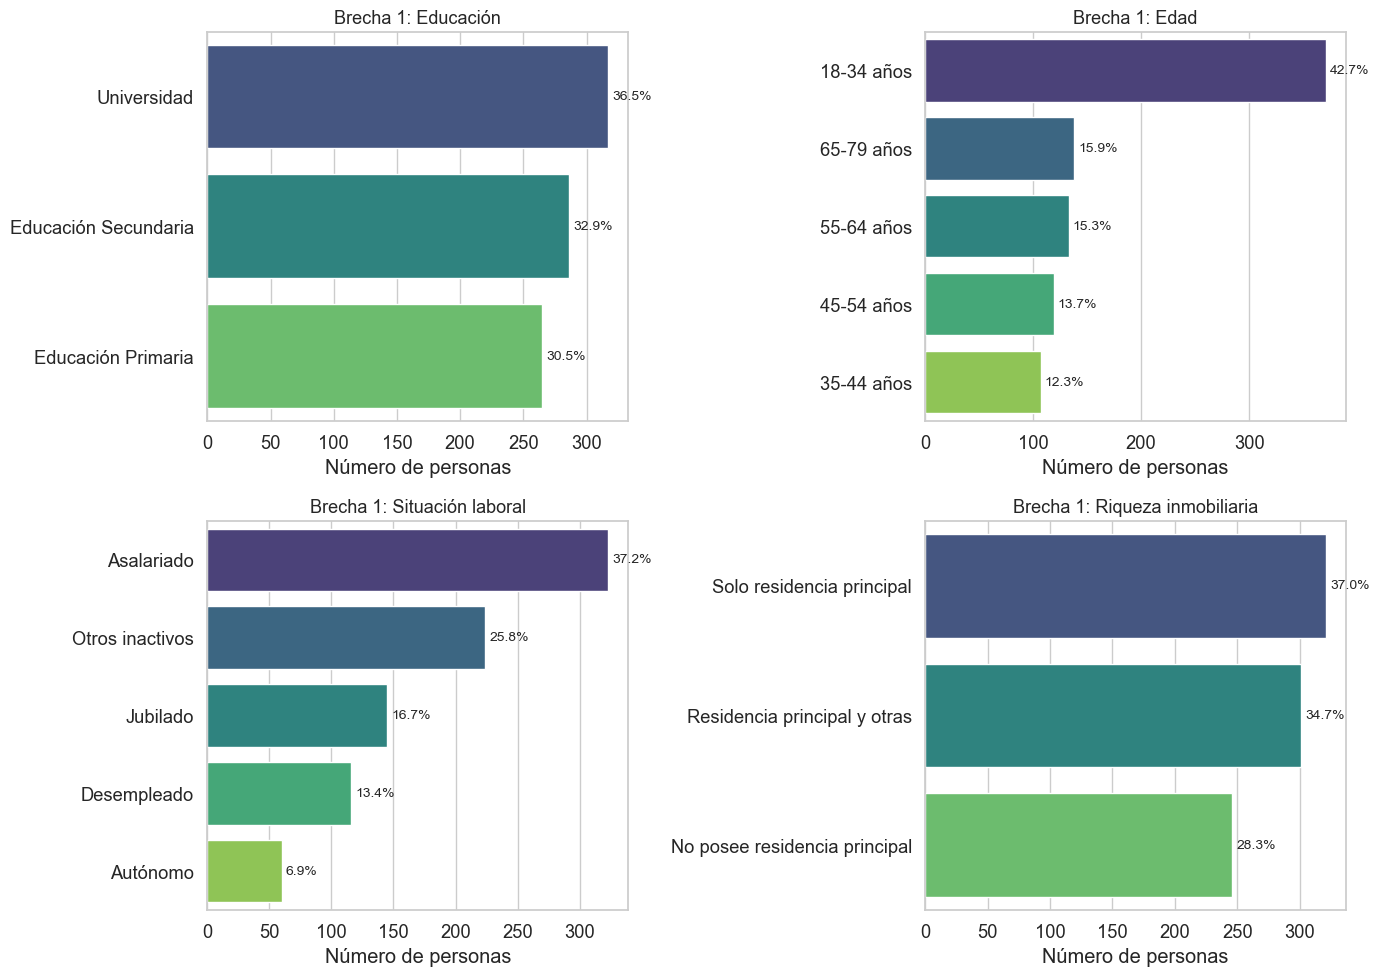

In [77]:
# Variables sociodemográficas con nombres reales
variables = {
    "cat_educacion": "Educación",
    "edad_grupo": "Edad",
    "estado_laboral": "Situación laboral",
    "riq_inmob": "Riqueza inmobiliaria"
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (var, titulo) in zip(axes, variables.items()):
    
    counts = brecha1[var].value_counts()
    total = counts.sum()
    porcentajes = counts / total

    sns.barplot(
        y=counts.index,
        x=counts.values,
        ax=ax,
        palette="viridis"
    )

    ax.set_title(f"Brecha 1: {titulo}", fontsize=13)
    ax.set_xlabel("Número de personas")
    ax.set_ylabel("")

    # Añadir porcentajes
    for i, (valor, pct) in enumerate(zip(counts.values, porcentajes.values)):
        ax.text(
            valor + max(counts.values)*0.01,
            i,
            f"{pct:.1%}",
            va="center",
            fontsize=10
        )

plt.tight_layout()
plt.show()

C:\Users\anaferrandbetes\AppData\Local\Temp\ipykernel_3308\3190442492.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\anaferrandbetes\AppData\Local\Temp\ipykernel_3308\3190442492.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\anaferrandbetes\AppData\Local\Temp\ipykernel_3308\3190442492.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\anaferrandbetes\AppData\Local\Temp\ipykernel_3308\3190442492.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0

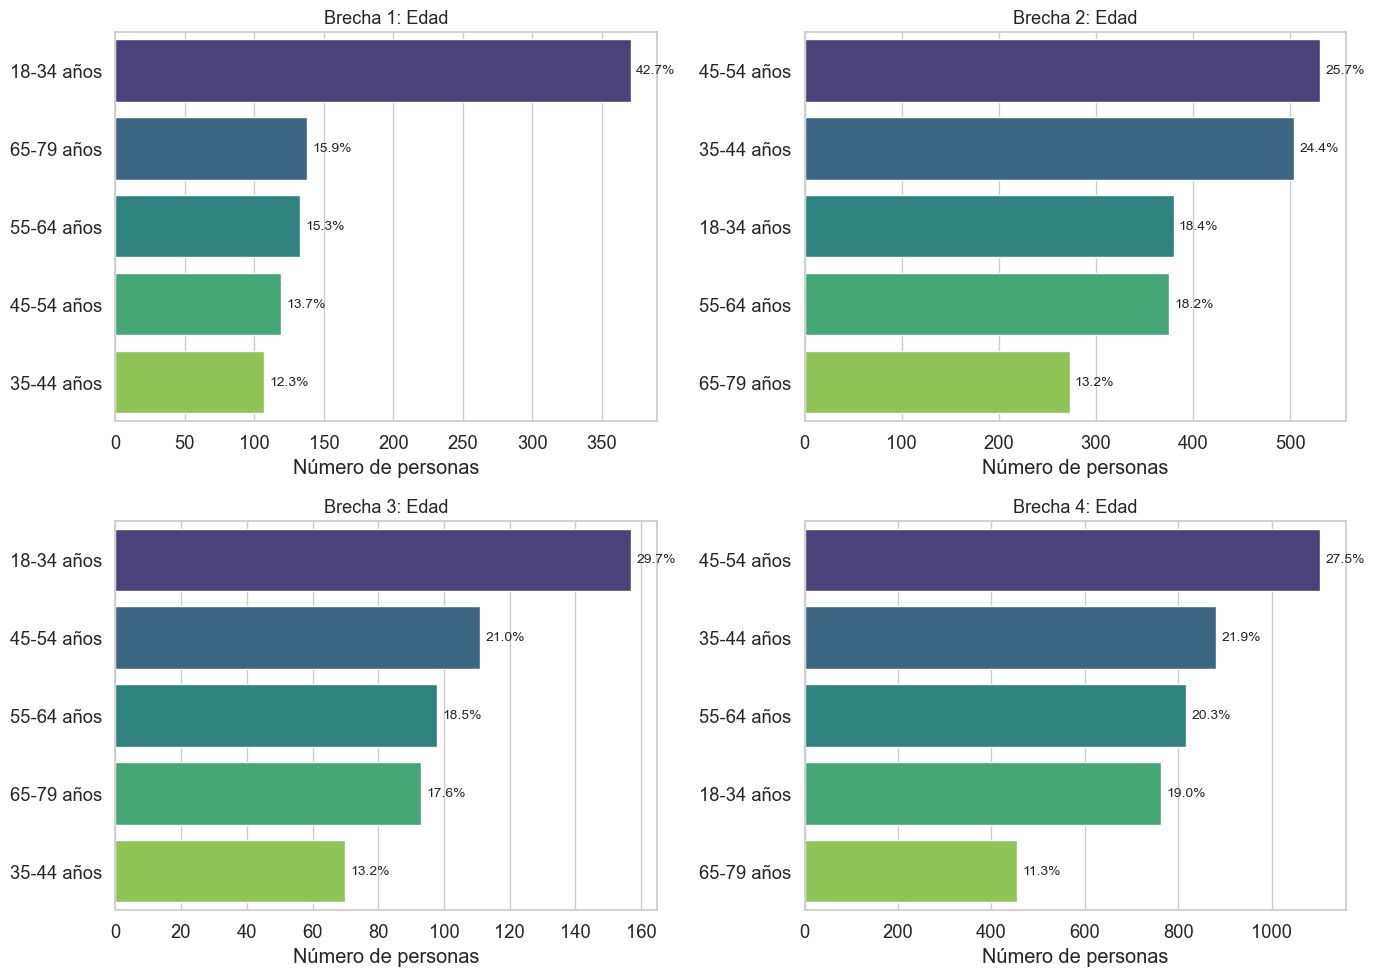

In [78]:
brechas = {
    "Brecha 1": brecha1,
    "Brecha 2": brecha2,
    "Brecha 3": brecha3,
    "Brecha 4": brecha4
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (nombre, df_b) in zip(axes, brechas.items()):
    
    counts = df_b["edad_grupo"].value_counts()
    total = counts.sum()
    porcentajes = counts / total

    sns.barplot(
        y=counts.index,
        x=counts.values,
        ax=ax,
        palette="viridis"
    )

    ax.set_title(f"{nombre}: Edad", fontsize=13)
    ax.set_xlabel("Número de personas")
    ax.set_ylabel("")

    for i, (valor, pct) in enumerate(zip(counts.values, porcentajes.values)):
        ax.text(valor + max(counts.values)*0.01, i, f"{pct:.1%}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

C:\Users\anaferrandbetes\AppData\Local\Temp\ipykernel_3308\2078724368.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\anaferrandbetes\AppData\Local\Temp\ipykernel_3308\2078724368.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\anaferrandbetes\AppData\Local\Temp\ipykernel_3308\2078724368.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\anaferrandbetes\AppData\Local\Temp\ipykernel_3308\2078724368.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0

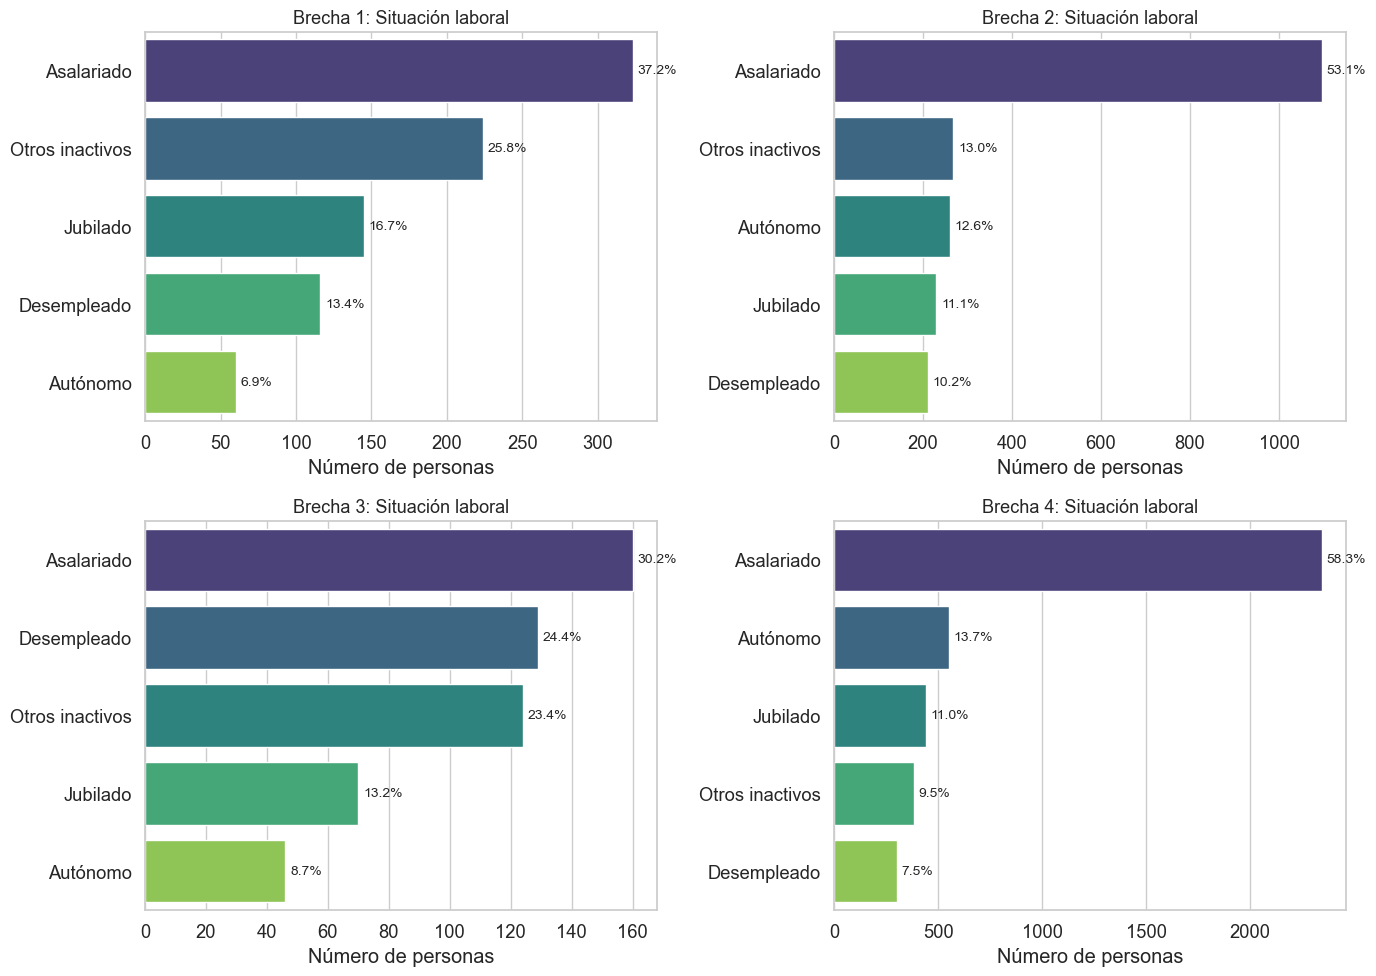

In [79]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (nombre, df_b) in zip(axes, brechas.items()):
    
    counts = df_b["estado_laboral"].value_counts()
    total = counts.sum()
    porcentajes = counts / total

    sns.barplot(
        y=counts.index,
        x=counts.values,
        ax=ax,
        palette="viridis"
    )

    ax.set_title(f"{nombre}: Situación laboral", fontsize=13)
    ax.set_xlabel("Número de personas")
    ax.set_ylabel("")

    for i, (valor, pct) in enumerate(zip(counts.values, porcentajes.values)):
        ax.text(valor + max(counts.values)*0.01, i, f"{pct:.1%}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

C:\Users\anaferrandbetes\AppData\Local\Temp\ipykernel_3308\3706438994.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\anaferrandbetes\AppData\Local\Temp\ipykernel_3308\3706438994.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\anaferrandbetes\AppData\Local\Temp\ipykernel_3308\3706438994.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\anaferrandbetes\AppData\Local\Temp\ipykernel_3308\3706438994.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0

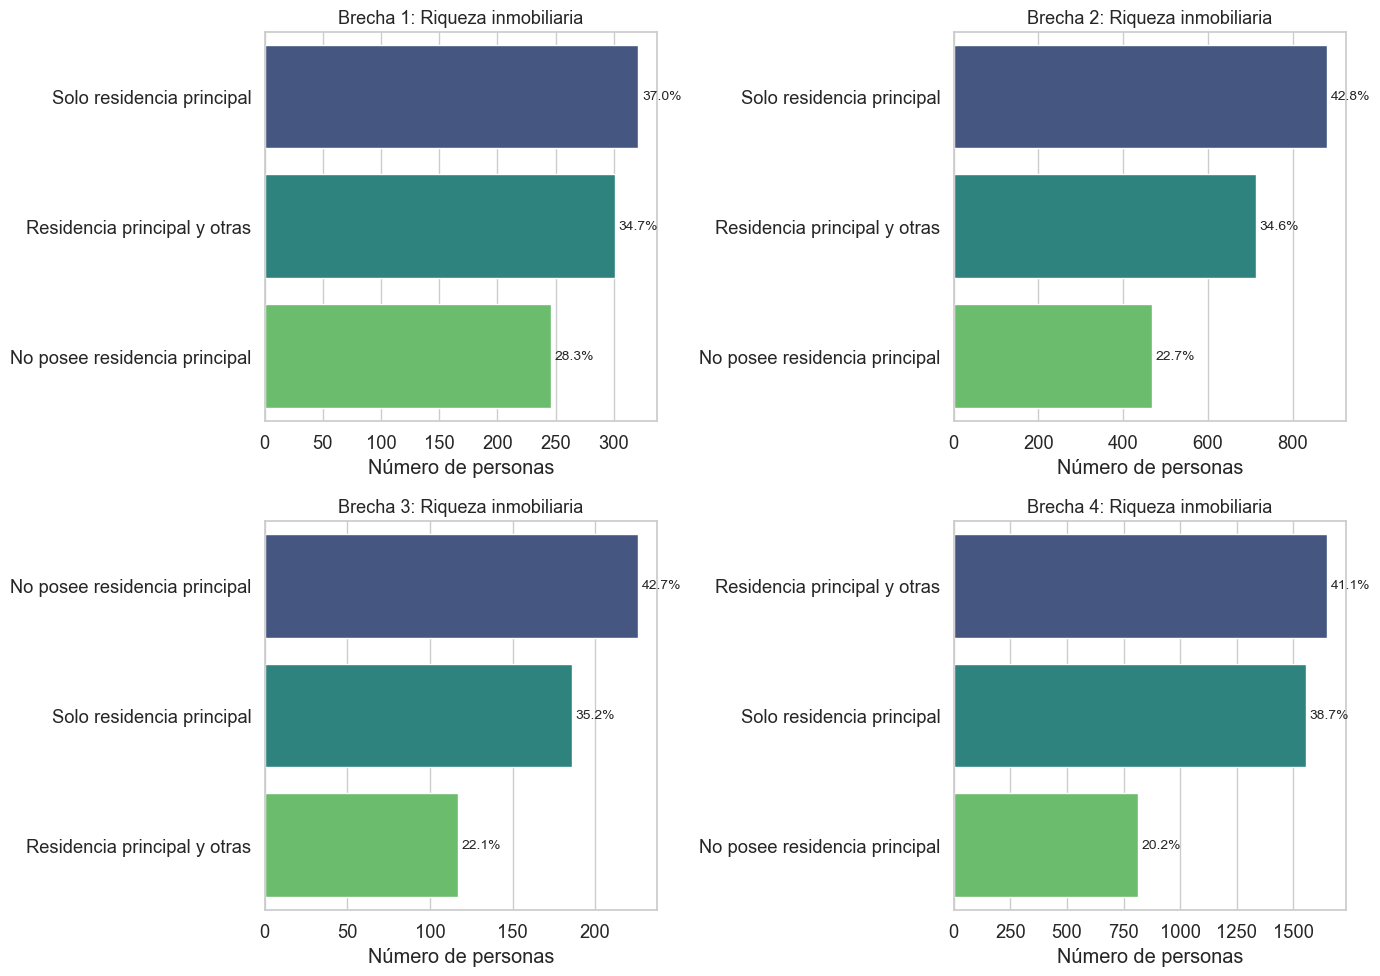

In [80]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (nombre, df_b) in zip(axes, brechas.items()):
    
    counts = df_b["riq_inmob"].value_counts()
    total = counts.sum()
    porcentajes = counts / total

    sns.barplot(
        y=counts.index,
        x=counts.values,
        ax=ax,
        palette="viridis"
    )

    ax.set_title(f"{nombre}: Riqueza inmobiliaria", fontsize=13)
    ax.set_xlabel("Número de personas")
    ax.set_ylabel("")

    for i, (valor, pct) in enumerate(zip(counts.values, porcentajes.values)):
        ax.text(valor + max(counts.values)*0.01, i, f"{pct:.1%}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

#### 5.4.6 Radar chart de comparación de brechas
Este gráfico permite comparar actividad, complejidad, competencia financiera, competencia de producto y vulnerabilidad entre brechas.

C:\Users\anaferrandbetes\AppData\Local\Temp\ipykernel_3308\86882871.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brecha1["brecha"] = 1
C:\Users\anaferrandbetes\AppData\Local\Temp\ipykernel_3308\86882871.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brecha2["brecha"] = 2
C:\Users\anaferrandbetes\AppData\Local\Temp\ipykernel_3308\86882871.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

Se

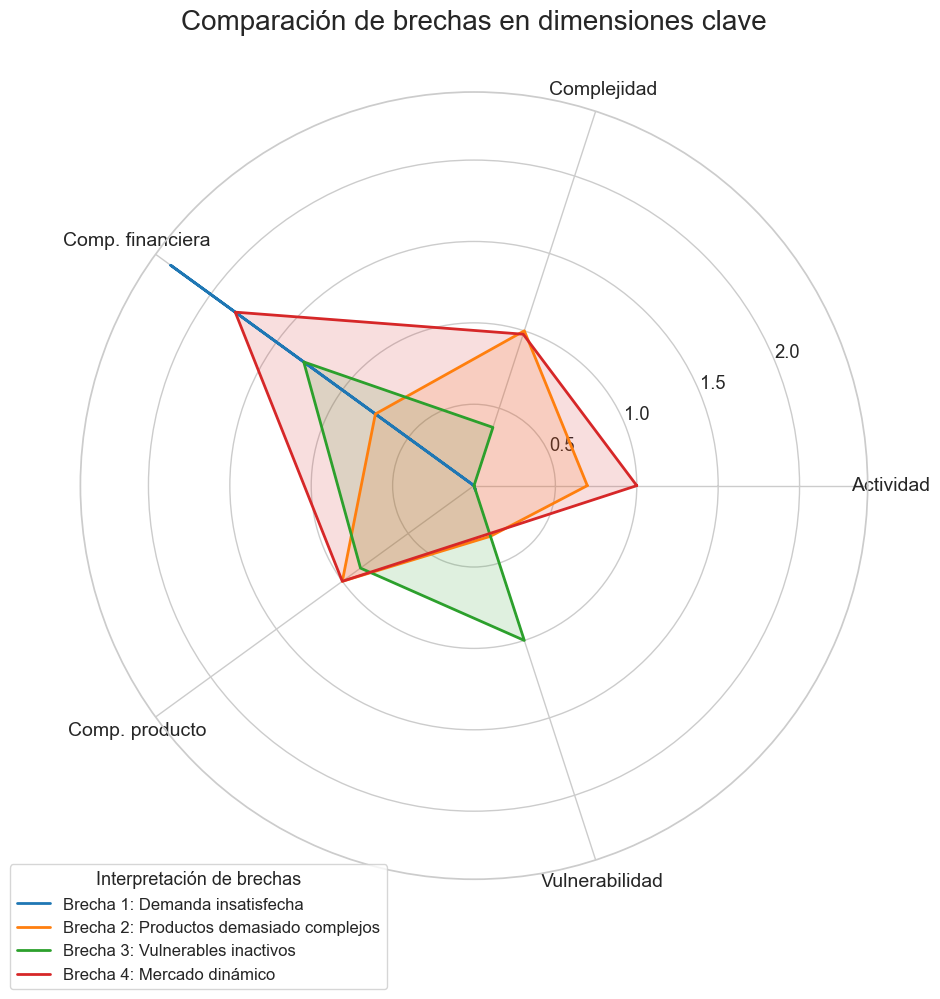

In [81]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Variables del radar
variables = ["actividad", "complejidad", "score_comp_fin", "comp_prod", "vulnerabilidad"]
labels = ["Actividad", "Complejidad", "Comp. financiera", "Comp. producto", "Vulnerabilidad"]
N = len(variables)

# Crear columna brecha
brecha1["brecha"] = 1
brecha2["brecha"] = 2
brecha3["brecha"] = 3
brecha4["brecha"] = 4

df_brechas = pd.concat([brecha1, brecha2, brecha3, brecha4])
df_brechas = df_brechas.groupby("brecha")[variables].mean().reset_index()

# Ángulos
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(12, 12))
ax = plt.subplot(111, polar=True)

colores = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

# Guardamos las líneas para la leyenda
line_handles = []

for i, row in df_brechas.iterrows():
    valores = row[variables].tolist()
    valores += valores[:1]

    # Dibujar línea
    linea, = ax.plot(angles, valores, linewidth=2, color=colores[i])
    ax.fill(angles, valores, alpha=0.15, color=colores[i])

    # Guardar handle de la línea (no del relleno)
    line_handles.append(linea)

# Etiquetas
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=14)

# Título separado
plt.title("Comparación de brechas en dimensiones clave", fontsize=20, pad=45)

# LEYENDA EDITABLE POR TI
plt.legend(
    line_handles,
    [
        "Brecha 1: Demanda insatisfecha",
        "Brecha 2: Productos demasiado complejos",
        "Brecha 3: Vulnerables inactivos",
        "Brecha 4: Mercado dinámico"
    ],
    loc="lower left",
    bbox_to_anchor=(-0.1, -0.15),
    fontsize=12,
    title="Interpretación de brechas",
    title_fontsize=13
)

plt.tight_layout(pad=5)
plt.show()

El radar chart muestra diferencias claras entre las brechas en cinco dimensiones clave: actividad, complejidad, competencia financiera, competencia de producto y vulnerabilidad.

- Brecha 1: Perfil muy homogéneo. Sus valores son similares en todas las dimensiones, lo que indica un grupo estable, equilibrado y con baja vulnerabilidad.

- Brecha 2: Presenta mayor vulnerabilidad y menor competencia financiera y de producto, lo que la convierte en el grupo más frágil y con mayor necesidad de apoyo.

- Brecha 3: Destaca por alta actividad y complejidad, reflejando un grupo más dinámico, con mayor interacción con productos financieros y situaciones más sofisticadas.

- Brecha 4: Muestra baja actividad y baja complejidad, indicando un perfil pasivo, con menor relación con productos financieros y necesidad de educación financiera básica.

En conjunto, el radar evidencia que cada brecha tiene un patrón propio y diferenciado, lo que permite orientar intervenciones y estrategias adaptadas a las características de cada grupo.



#### 5.4.7. Sankey diagram - Flujo entre competencias y actividad
Este Sankey muestra cómo se mueven las personas entre:
- competencia financiera
- competencia de producto
- actividad financiera
Es muy visual para explicar flujos


In [82]:
import plotly.graph_objects as go

# --- 1. Crear nodos ---
labels = [
    "Comp. financiera baja", "Comp. financiera alta",
    "Comp. producto baja", "Comp. producto alta",
    "Actividad baja", "Actividad alta"
]

# Posiciones horizontales (niveles)
x_positions = [0.0, 0.0,   0.5, 0.5,   1.0, 1.0]
y_positions = [0.2, 0.8,   0.2, 0.8,   0.2, 0.8]

# --- 2. Crear enlaces (flujos) ---
source = []
target = []
value = []

# Flujo 1: comp_fin_bin → comp_prod
for cf in [0, 1]:
    for cp in [0, 1]:
        count = len(df[(df.comp_fin_bin == cf) & (df.comp_prod == cp)])
        source.append(cf)
        target.append(2 + cp)
        value.append(count)

# Flujo 2: comp_prod → actividad
for cp in [0, 1]:
    for act in [0, 1]:
        count = len(df[(df.comp_prod == cp) & (df.actividad == act)])
        source.append(2 + cp)
        target.append(4 + act)
        value.append(count)

# --- 3. Calcular porcentajes ---
total = sum(value)
percentages = [v / total * 100 for v in value]

# --- 4. Construcción del Sankey ---
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
        x=x_positions,
        y=y_positions
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        customdata=percentages,
        hovertemplate="<b>%{value} personas</b><br>%{customdata:.1f}%<extra></extra>"
    )
)])

fig.update_layout(
    title_text="Flujos entre competencias y actividad financiera",
    font_size=14
)

fig.show()

El Sankey muestra cómo las personas se mueven entre tres dimensiones: competencia financiera, competencia de producto y actividad. El patrón general es muy claro:

- Quienes tienen baja competencia financiera tienden a concentrarse también en baja competencia de producto, y desde ahí pasan mayoritariamente a baja actividad.

- En cambio, quienes parten de alta competencia financiera fluyen con más frecuencia hacia alta competencia de producto, y terminan en alta actividad.

En resumen: el gráfico evidencia un camino coherente:

- más competencia → más actividad,
- menos competencia → menos actividad.

Es decir, las competencias financieras y de producto actúan como puertas de entrada que condicionan el nivel de actividad posterior.


### 5.5. Conclusiones

El análisis de brechas revela cuatro perfiles financieros claramente diferenciados en la población, definidos por sus niveles de competencia financiera, competencia de producto, actividad y vulnerabilidad. Estos perfiles muestran comportamientos y necesidades muy distintas, lo que confirma que una oferta única no es suficiente para atender a todos los segmentos.

Los patrones observados indican que:
- Mayor competencia → mayor actividad y uso de productos financieros.
- Menor competencia → menor actividad y mayor vulnerabilidad.

Este vínculo estructural implica que las competencias financieras condicionan directamente el comportamiento financiero.

**Los resultados muestran que es necesario adaptar las ofertas actuales y desarrollar soluciones específicas para cada brecha, alineadas con las tendencias nacionales de comportamiento y competencias financieras.**

**Propuestas de negocio por brecha**

Brecha 1 – Perfil estable
- Mantener y reforzar la relación con mejoras incrementales y programas de fidelización.

Brecha 2 – Perfil vulnerable y con baja competencia
- Productos simples y de bajo riesgo.
- Educación financiera estructurada.
- Acompañamiento y comunicación clara.

Brecha 3 – Perfil activo y complejo
- Productos avanzados (inversión, planificación).
- Herramientas digitales sofisticadas.
- Servicios personalizados.

Brecha 4 – Perfil pasivo y poco vinculado
- Productos de entrada muy sencillos.
- Estrategias de activación y onboarding guiado.
- Contenidos pedagógicos básicos.